In [ ]:
# ============================================================
# MAPCT-Diffusion: Generative Diffusion for Regimen Generation
# ============================================================
# Part 1: Imports & Reproducibility
# ============================================================

import os
import re
import random
import warnings
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc
from scipy.stats import pearsonr, spearmanr

from sentence_transformers import SentenceTransformer

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Suppress warnings
warnings.filterwarnings('ignore')


Using device: cpu


In [ ]:
# ============================================================
# Part 2: Data Loading & Normalization
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")


Mounted at /content/drive
Loaded 4547 patients, 164 mechanism entries


In [ ]:
# ============================================================
# Drug name normalization functions
# ============================================================
def normalize_drug_name(name: str) -> str:
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name

def sort_drug_combo(combo: str) -> str:
    if not isinstance(combo, str):
        return ""
    drugs = sorted(d.strip() for d in combo.split(",") if d.strip())
    return ", ".join(drugs)

def split_combo(combo: str):
    return [d.strip() for d in combo.split(",") if d.strip()]

# Normalize drug names
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

# Normalize mechanism table
mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

print("✅ Drug names normalized")




✅ Drug names normalized


In [ ]:
# ============================================================
# Part 3: LEAKAGE‑FREE SPLIT BY REGIMEN (GROUP‑BASED)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: separate test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: from remaining groups, take 20% for validation (→ 16% of patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert relative indices to original indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test already defined

print(f"Leakage‑free splits: Train={len(idx_train)}, Val={len(idx_val)}, Test={len(idx_test)}")

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"
print("✅ Verified: train and test have no common regimens.")

# ============================================================
# Drug vocabulary & multi‑hot targets (unchanged from here)
# ============================================================
# Build vocabulary from TRAIN only
train_drugs_set = set()
for combo in clinic_df.iloc[idx_train]["merged_drugs_norm"]:
    for drug in split_combo(combo):
        train_drugs_set.add(drug)

drug_to_idx = {drug: i for i, drug in enumerate(sorted(train_drugs_set))}
idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
num_drugs = len(drug_to_idx)

drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs} (from training data only)")

# Filter val/test to train vocabulary
def filter_to_train_vocab(combo):
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

clinic_df_original = clinic_df.copy()
clinic_df = clinic_df.iloc[idx_all].copy()
clinic_df.loc[idx_val, "merged_drugs_norm"] = clinic_df.loc[idx_val, "merged_drugs_norm"].apply(filter_to_train_vocab)
clinic_df.loc[idx_test, "merged_drugs_norm"] = clinic_df.loc[idx_test, "merged_drugs_norm"].apply(filter_to_train_vocab)

# Multi-hot drug targets
def encode_regimen_multi_hot(combo, drug_to_idx):
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

drug_multi_hot = np.zeros((len(clinic_df), num_drugs), dtype=np.float32)
for i, combo in enumerate(clinic_df["merged_drugs_norm"]):
    drug_multi_hot[i] = encode_regimen_multi_hot(combo, drug_to_idx)

y_drug_tensor = torch.tensor(drug_multi_hot, dtype=torch.float32)


Drug vocabulary size: 151 (from training data only)
Drug vocabulary list length: 151


In [ ]:
# ============================================================
# Part 4: Clinical Preprocessing (LEAK-PROOF)
# ============================================================

numeric_cols = ["fbs", "glu", "hba1c", "TG", "cho", "LDL", "HDL", "UA", "Na", "K", "Ca", "Vit D", "age"]
categorical_cols = ["sex", "fbs_category", "tg_category", "cho_category"]

# Convert to numeric
clinic_df[numeric_cols] = clinic_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Create split dataframes
clinic_df_train = clinic_df.iloc[idx_train].copy()
clinic_df_val = clinic_df.iloc[idx_val].copy()
clinic_df_test = clinic_df.iloc[idx_test].copy()

# Fill missing using TRAIN only
train_means = clinic_df_train[numeric_cols].mean()

for df in [clinic_df_train, clinic_df_val, clinic_df_test]:
    df[numeric_cols] = df[numeric_cols].fillna(train_means)
    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")

# Preprocessor (fit on TRAIN only)
clinical_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_cols)
], remainder="drop")

clinical_preprocessor.fit(clinic_df_train[numeric_cols + categorical_cols])

# Transform each split separately
X_clin_train = torch.tensor(
    clinical_preprocessor.transform(clinic_df_train[numeric_cols + categorical_cols]),
    dtype=torch.float32
)
X_clin_val = torch.tensor(
    clinical_preprocessor.transform(clinic_df_val[numeric_cols + categorical_cols]),
    dtype=torch.float32
)
X_clin_test = torch.tensor(
    clinical_preprocessor.transform(clinic_df_test[numeric_cols + categorical_cols]),
    dtype=torch.float32
)

# Drug labels for each split
y_drug_train = y_drug_tensor[idx_train]
y_drug_val = y_drug_tensor[idx_val]
y_drug_test = y_drug_tensor[idx_test]

# Move to device
X_clin_train = X_clin_train.to(device)
X_clin_val = X_clin_val.to(device)
X_clin_test = X_clin_test.to(device)
y_drug_train = y_drug_train.to(device)
y_drug_val = y_drug_val.to(device)
y_drug_test = y_drug_test.to(device)

print(f"Clinical features: {X_clin_train.shape[1]}")
print(f"Train/Val/Test sizes: {len(X_clin_train)}/{len(X_clin_val)}/{len(X_clin_test)}")



Clinical features: 25
Train/Val/Test sizes: 2910/727/910


In [ ]:
# ============================================================
# Part 5: TRUE MAPCT-v2 MECHANISM ENCODER (Structured + Semantic)
# ============================================================

def stable_hash(x: str, mod: int) -> int:
    return int(hashlib.md5(x.encode()).hexdigest(), 16) % mod

class StructuredMechanismEncoder:
    def __init__(self, struct_dim=256):
        self.struct_dim = struct_dim
        self.n_fields = 8
        self.slice_len = struct_dim // self.n_fields

        self.offsets = {
            "chembl": 0,
            "target_ids": self.slice_len,
            "uniprot_ids": 2 * self.slice_len,
            "mesh_ids": 3 * self.slice_len,
            "pathway_ids": 4 * self.slice_len,
            "atc_codes": 5 * self.slice_len,
            "pharm_class": 6 * self.slice_len,
            "mechanism_ids": 7 * self.slice_len,
        }

        self.field_columns = {
            "chembl": "ChEMBL ID",
            "target_ids": "Target IDs",
            "uniprot_ids": "UniProt Target ID(s)",
            "mesh_ids": "MeSH Mechanism ID(s)",
            "pathway_ids": "Pathway IDs",
            "atc_codes": "ATC Code(s)",
            "pharm_class": "Pharmacologic Class",
            "mechanism_ids": "Mechanism IDs",
        }

    def encode_field(self, values, field_name):
        vector = torch.zeros(self.slice_len)
        if values is None:
            return vector

        if isinstance(values, pd.Series):
            values = values.dropna().tolist()
        elif isinstance(values, str):
            values = [v.strip() for v in values.split(";") if v.strip()]
        elif not isinstance(values, (list, tuple)):
            values = [values]

        for v in values:
            v_str = str(v).strip()
            if v_str and v_str not in ["", "nan", "None"]:
                idx = stable_hash(v_str, self.slice_len)
                vector[idx] += 1.0

        return vector

    def encode(self, row):
        vector = torch.zeros(self.struct_dim)
        for field_name, col_name in self.field_columns.items():
            if col_name in row.index:
                vals = row[col_name]
                field_vec = self.encode_field(vals, field_name)
                offset = self.offsets[field_name]
                vector[offset:offset + self.slice_len] = field_vec

        if torch.norm(vector) > 0:
            vector = vector / torch.norm(vector)
        return vector

# Load semantic model
semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
SEM_DIM = semantic_model.get_sentence_embedding_dimension()
print(f"Semantic embedding dimension: {SEM_DIM}")

STRUCT_DIM = 256
FULL_DIM = STRUCT_DIM + SEM_DIM
print(f"Total embedding dimension: {FULL_DIM}")

class FusedMechanismEncoder:
    def __init__(self, struct_dim=256, sem_dim=384):
        self.struct_encoder = StructuredMechanismEncoder(struct_dim)
        self.sem_dim = sem_dim
        self.struct_dim = struct_dim
        self.fused_dim = struct_dim + sem_dim

    def encode_drug(self, drug_name, mech_df):
        row = mech_df[mech_df["Drug Name Norm"] == drug_name]
        if len(row) == 0:
            return torch.zeros(self.fused_dim)

        row = row.iloc[0]

        # Structured encoding
        struct_vec = self.struct_encoder.encode(row)

        # Semantic encoding
        text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]
        text_parts = []
        for col in text_cols:
            if col in row and pd.notna(row[col]):
                text_parts.append(str(row[col]))

        if text_parts:
            full_text = " | ".join(text_parts)
            with torch.no_grad():
                sem_vec = semantic_model.encode(full_text, convert_to_tensor=True)
                sem_vec = F.normalize(sem_vec, dim=0).cpu()
        else:
            sem_vec = torch.zeros(self.sem_dim)

        # Fuse
        fused = torch.cat([struct_vec, sem_vec], dim=0)
        if torch.norm(fused) > 0:
            fused = fused / torch.norm(fused)

        return fused

# Build embeddings
train_drugs = set(drug_to_idx.keys())
fused_encoder = FusedMechanismEncoder(struct_dim=STRUCT_DIM, sem_dim=SEM_DIM)

drug_embeddings = {}
for drug in tqdm(train_drugs, desc="Building mechanism embeddings"):
    drug_embeddings[drug] = fused_encoder.encode_drug(drug, mech_df)

print(f"✅ Built embeddings for {len(drug_embeddings)} drugs")




modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic embedding dimension: 384
Total embedding dimension: 640


Building mechanism embeddings: 100%|██████████| 151/151 [00:04<00:00, 33.75it/s]

✅ Built embeddings for 151 drugs


In [ ]:
# ============================================================
# Part 6: Patient Drug Sequences
# ============================================================

MAX_DRUGS = 10

def build_drug_sequence(combo):
    drugs = split_combo(combo)[:MAX_DRUGS]

    seq = []
    roles = []
    for drug in drugs:
        emb = drug_embeddings.get(drug, torch.zeros(FULL_DIM))
        seq.append(emb)
        roles.append(1)

    num_real = len(seq)
    if num_real < MAX_DRUGS:
        seq += [torch.zeros(FULL_DIM)] * (MAX_DRUGS - num_real)
        roles += [0] * (MAX_DRUGS - num_real)

    mask = torch.zeros(MAX_DRUGS, dtype=torch.bool)
    mask[:num_real] = True

    return torch.stack(seq), torch.tensor(roles, dtype=torch.long), mask

# Build tensors
print("Building drug sequence tensors...")
X_drug = []
X_role = []
X_mask = []

for combo in tqdm(clinic_df["merged_drugs_norm"], desc="Processing regimens"):
    seq, roles, mask = build_drug_sequence(combo)
    X_drug.append(seq)
    X_role.append(roles)
    X_mask.append(mask)

X_drug_tensor = torch.stack(X_drug)
X_role_tensor = torch.stack(X_role)
X_mask_tensor = torch.stack(X_mask)

# Split
X_drug_train = X_drug_tensor[idx_train].to(device)
X_drug_val = X_drug_tensor[idx_val].to(device)
X_drug_test = X_drug_tensor[idx_test].to(device)

X_role_train = X_role_tensor[idx_train].to(device)
X_role_val = X_role_tensor[idx_val].to(device)
X_role_test = X_role_tensor[idx_test].to(device)

mask_train = X_mask_tensor[idx_train].to(device)
mask_val = X_mask_tensor[idx_val].to(device)
mask_test = X_mask_tensor[idx_test].to(device)

print(f"✅ Drug sequences built: {X_drug_train.shape}")


Building drug sequence tensors...


Processing regimens: 100%|██████████| 4547/4547 [00:00<00:00, 10364.47it/s]


✅ Drug sequences built: torch.Size([2910, 10, 640])


In [ ]:
# ============================================================
# ADD THIS SECTION AFTER Part 6 (around line 500)
# ============================================================

# ============================================================
# Part 6.5: CREATE DATALOADERS
# ============================================================

from torch.utils.data import Dataset, DataLoader

class MAPCTDataset(Dataset):
    def __init__(self, clinical_tensor, drug_labels, mech_tensor, mask_tensor):
        self.clinical = clinical_tensor
        self.labels = drug_labels
        self.mech_tensor = mech_tensor
        self.mask = mask_tensor

    def __len__(self):
        return len(self.clinical)

    def __getitem__(self, idx):
        return {
            'clinical': self.clinical[idx],
            'label': self.labels[idx],
            'mech_tensor': self.mech_tensor[idx],
            'mech_mask': self.mask[idx]
        }

# Create datasets
train_dataset = MAPCTDataset(X_clin_train, y_drug_train, X_drug_train, mask_train)
val_dataset = MAPCTDataset(X_clin_val, y_drug_val, X_drug_val, mask_val)
test_dataset = MAPCTDataset(X_clin_test, y_drug_test, X_drug_test, mask_test)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders created: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

✅ DataLoaders created: Train=91, Val=23, Test=29


In [ ]:
# ============================================================
# Part 7: MAPCT-Diffusion Model Architecture
# ============================================================

class SinusoidalPositionEmbedding(nn.Module):
    """Sinusoidal time embedding for diffusion timesteps"""
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
        emb = timesteps[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

class DrugEncoder(nn.Module):
    def __init__(self, emb_dim=FULL_DIM, latent_dim=128, n_heads=4, n_layers=2, max_drugs=10):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_drugs, emb_dim) * 0.01)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.proj = nn.Linear(emb_dim, latent_dim)

    def forward(self, drug_seq, mask, roles=None):
        x = drug_seq + self.pos_emb[:, :drug_seq.size(1), :]
        x = self.transformer(x, src_key_padding_mask=~mask)
        mask_expanded = mask.unsqueeze(-1).float()
        pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        out = self.proj(pooled)
        return F.normalize(out, dim=1)

class DrugDecoder(nn.Module):
    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)

class DiffusionDenoiser(nn.Module):
    """
    Diffusion denoiser that takes noisy latent, timestep, and conditioning
    """
    def __init__(self, latent_dim=128, time_dim=128, cond_dim=128, hidden_dim=256):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbedding(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.denoiser = nn.Sequential(
            nn.Linear(latent_dim + hidden_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, z_noisy, timesteps, conditioning):
        # Time embedding
        t_emb = self.time_mlp(timesteps)

        # Conditioning embedding
        c_emb = self.cond_mlp(conditioning)

        # Concatenate and denoise
        z_input = torch.cat([z_noisy, t_emb, c_emb], dim=-1)
        z_pred = self.denoiser(z_input)

        return z_pred

# ============================================================
# Place this AFTER DiffusionDenoiser and BEFORE MAPCTDiffusion
# ============================================================

class ContrastiveProjection(nn.Module):
    """Projection head for contrastive learning"""
    def __init__(self, latent_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, z):
        return F.normalize(self.net(z), dim=1)


class MAPCTDiffusion(nn.Module):
    """
    MAPCT-Diffusion: Generative Diffusion Model for Regimen Generation
    """
    def __init__(self, clin_dim, num_drugs, latent_dim=128, n_timesteps=200,
                 beta_start=1e-4, beta_end=0.02, schedule_type="linear"):
        super().__init__()

        # Encoders
        self.clinical_encoder = ClinicalEncoder(clin_dim, latent_dim)
        self.drug_encoder = DrugEncoder(emb_dim=FULL_DIM, latent_dim=latent_dim)

        self.clinical_proj = ContrastiveProjection(latent_dim, proj_dim=64)
        self.drug_proj = ContrastiveProjection(latent_dim, proj_dim=64)

        # Decoders
        self.drug_decoder = DrugDecoder(latent_dim, num_drugs=num_drugs)

        # Diffusion components
        self.latent_dim = latent_dim
        self.n_timesteps = n_timesteps

        # ============================================================
        # FIX: Create noise schedule and register buffers correctly
        # ============================================================

        # Create betas based on schedule type
        if schedule_type == "linear":
            betas = torch.linspace(beta_start, beta_end, n_timesteps)
        elif schedule_type == "cosine":
            # Cosine schedule (improved for diffusion)
            s = 0.008
            steps = torch.arange(n_timesteps + 1) / n_timesteps
            alphas_cumprod = torch.cos((steps + s) / (1 + s) * np.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
            betas = torch.clip(betas, 0.0001, 0.9999)
        else:
            betas = torch.linspace(beta_start, beta_end, n_timesteps)

        # Calculate derived values
        alphas = 1 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

        # ============================================================
        # FIX: Register buffers directly WITHOUT creating attributes first
        # ============================================================
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)
        self.register_buffer('sqrt_alphas_cumprod', sqrt_alphas_cumprod)
        self.register_buffer('sqrt_one_minus_alphas_cumprod', sqrt_one_minus_alphas_cumprod)

        # Denoiser
        self.denoiser = DiffusionDenoiser(
            latent_dim=latent_dim,
            time_dim=128,
            cond_dim=latent_dim,
            hidden_dim=256
        )

    def q_sample(self, z0, timesteps, noise=None):
        """Forward diffusion: add noise to z0"""
        if noise is None:
            noise = torch.randn_like(z0)

        sqrt_alpha_cumprod = self.sqrt_alphas_cumprod[timesteps].view(-1, 1)
        sqrt_one_minus_alpha_cumprod = self.sqrt_one_minus_alphas_cumprod[timesteps].view(-1, 1)

        z_noisy = sqrt_alpha_cumprod * z0 + sqrt_one_minus_alpha_cumprod * noise
        return z_noisy, noise

    def p_sample(self, z_noisy, timesteps, conditioning):
        """Reverse diffusion: denoise one step"""
        # Predict noise
        predicted_noise = self.denoiser(z_noisy, timesteps, conditioning)

        # Get coefficients
        betas_t = self.betas[timesteps].view(-1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[timesteps].view(-1, 1)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / self.alphas[timesteps]).view(-1, 1)

        # Compute mean
        z_pred = sqrt_recip_alphas_t * (z_noisy - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t)

        # Add noise (except at t=0)
        noise = torch.randn_like(z_pred) if timesteps.min() > 0 else 0

        posterior_variance = self.betas[timesteps].view(-1, 1)
        std = torch.sqrt(posterior_variance)
        return z_pred + std * noise


    def sample(self, conditioning, num_samples=None):
        """Generate samples from noise"""
        if num_samples is None:
            num_samples = conditioning.shape[0]

        # Start from pure noise
        z = torch.randn(num_samples, self.latent_dim, device=conditioning.device)

        # Iteratively denoise
        for t in reversed(range(self.n_timesteps)):
            t_tensor = torch.full((num_samples,), t, device=conditioning.device, dtype=torch.long)
            z = self.p_sample(z, t_tensor, conditioning)

        return z

    def forward_clinical_to_drug(self, x_clin):
        z_clin = self.clinical_encoder(x_clin)
        return self.drug_decoder(z_clin), z_clin

    def forward_diffusion(self, z_drug, conditioning, timesteps):
        """Forward diffusion for training"""
        noise = torch.randn_like(z_drug)
        z_noisy, _ = self.q_sample(z_drug, timesteps, noise)
        predicted_noise = self.denoiser(z_noisy, timesteps, conditioning)
        return predicted_noise, noise

    def forward_drug_encoding(self, drug_seq, mask, roles=None):
        return self.drug_encoder(drug_seq, mask, roles)

    def generate_regimen(self, clinical_tensor, threshold=0.3):
        """Generate a regimen for a patient"""
        self.eval()
        with torch.no_grad():
            # Encode patient
            z_clin = self.clinical_encoder(clinical_tensor)

            # Generate via diffusion
            z_gen = self.sample(z_clin)

            # Decode to drugs
            logits = self.drug_decoder(z_gen)
            probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

            # Get drugs above threshold
            drugs = [idx_to_drug[i] for i, p in enumerate(probs) if p > threshold]
            probs_list = [p for p in probs if p > threshold]

            return list(zip(drugs, probs_list))


In [ ]:
# ============================================================
# Part 8: Training Functions (CORRECTED)
# ============================================================

class MAPCTDiffusionTrainer:
    def __init__(self, model, device, drug_vocab, drug_to_idx):
        self.model = model.to(device)
        self.device = device
        self.drug_vocab = drug_vocab
        self.drug_to_idx = drug_to_idx
        self.num_drugs = len(drug_vocab)

        # ============================================================
        # FIX 1: ADD PROJECTION HEAD PARAMETERS TO OPTIMIZER
        # ============================================================
        self.opt_enc = torch.optim.Adam(
            list(self.model.clinical_encoder.parameters()) +
            list(self.model.drug_encoder.parameters()) +
            list(self.model.clinical_proj.parameters()) +      # ADD THIS
            list(self.model.drug_proj.parameters()),           # ADD THIS
            lr=1e-3, weight_decay=1e-5
        )

        self.opt_dec = torch.optim.Adam(
            list(self.model.drug_decoder.parameters()),
            lr=1e-3, weight_decay=1e-5
        )
        self.opt_diff = torch.optim.Adam(
            list(self.model.denoiser.parameters()),
            lr=1e-4, weight_decay=1e-5
        )

        # Loss weights (increased contrast)
        self.alpha_contrast = 0.7  # Increased from 0.5 to 0.7 for better alignment
        self.beta_drug = 1.0
        self.gamma_diff = 1.0

        # Mixed precision training
        self.scaler = GradScaler()

        # Training history
        self.train_history = {
            'loss': [], 'contrast': [], 'drug': [], 'diffusion': []
        }

    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()

        total_loss = 0
        total_contrast = 0
        total_drug = 0
        total_diff = 0

        for batch in train_loader:
            # Handle different batch formats
            if isinstance(batch, dict):
                clinical = batch['clinical'].to(self.device)
                labels = batch['label'].to(self.device)
                mech_tensor = batch['mech_tensor'].to(self.device)
                mech_mask = batch['mech_mask'].to(self.device)
            else:
                # Assume tuple format (clinical, labels, mech_tensor, mech_mask)
                clinical, labels, mech_tensor, mech_mask = batch
                clinical = clinical.to(self.device)
                labels = labels.to(self.device)
                mech_tensor = mech_tensor.to(self.device)
                mech_mask = mech_mask.to(self.device)

            with autocast():
                # Encode
                z_clin = self.model.clinical_encoder(clinical)
                z_drug = self.model.drug_encoder(mech_tensor, mech_mask)

                # 1. Drug prediction loss
                drug_logits = self.model.drug_decoder(z_clin)
                loss_drug = F.binary_cross_entropy_with_logits(drug_logits, labels)

                # Apply projection heads
                z_clin_proj = self.model.clinical_proj(z_clin)
                z_drug_proj = self.model.drug_proj(z_drug)

                # 2. Contrastive loss (lower temperature for stronger alignment)
                loss_contrast = contrastive_loss(z_clin_proj, z_drug_proj, temperature=0.05)

                # 3. Diffusion loss
                timesteps = torch.randint(0, self.model.n_timesteps, (z_drug.shape[0],), device=self.device)
                predicted_noise, true_noise = self.model.forward_diffusion(z_drug, z_clin, timesteps)
                loss_diff = diffusion_loss(predicted_noise, true_noise)

                # Combined loss
                loss = self.alpha_contrast * loss_contrast + self.beta_drug * loss_drug + self.gamma_diff * loss_diff

            # Backward
            self.opt_enc.zero_grad()
            self.opt_dec.zero_grad()
            self.opt_diff.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.opt_enc)
            self.scaler.step(self.opt_dec)
            self.scaler.step(self.opt_diff)
            self.scaler.update()

            total_loss += loss.item()
            total_contrast += loss_contrast.item()
            total_drug += loss_drug.item()
            total_diff += loss_diff.item()

        n_batches = len(train_loader)
        return {
            'loss': total_loss / n_batches,
            'contrast': total_contrast / n_batches,
            'drug': total_drug / n_batches,
            'diffusion': total_diff / n_batches
        }

    def validate(self, val_loader):
        """Validate the model"""
        self.model.eval()

        total_contrast = 0
        total_drug_acc = 0

        with torch.no_grad():
            for batch in val_loader:
                # ============================================================
                # FIX 2: ADD BATCH VARIABLE EXTRACTION
                # ============================================================
                if isinstance(batch, dict):
                    clinical = batch['clinical'].to(self.device)
                    labels = batch['label'].to(self.device)
                    mech_tensor = batch['mech_tensor'].to(self.device)
                    mech_mask = batch['mech_mask'].to(self.device)
                else:
                    clinical, labels, mech_tensor, mech_mask = batch
                    clinical = clinical.to(self.device)
                    labels = labels.to(self.device)
                    mech_tensor = mech_tensor.to(self.device)
                    mech_mask = mech_mask.to(self.device)

                # Encode
                z_clin = self.model.clinical_encoder(clinical)
                z_drug = self.model.drug_encoder(mech_tensor, mech_mask)

                # Use projection heads in validation
                z_clin_proj = self.model.clinical_proj(z_clin)
                z_drug_proj = self.model.drug_proj(z_drug)

                # Contrastive loss
                loss_contrast = contrastive_loss(z_clin_proj, z_drug_proj, temperature=0.05)
                total_contrast += loss_contrast.item()

                # Drug prediction accuracy
                drug_logits = self.model.drug_decoder(z_clin)
                drug_probs = torch.sigmoid(drug_logits)
                preds = (drug_probs > 0.5).float()
                total_drug_acc += (preds == labels).float().mean().item()

        n_batches = len(val_loader)
        return {
            'contrast_loss': total_contrast / n_batches,
            'drug_accuracy': total_drug_acc / n_batches
        }

    def train(self, train_loader, val_loader, epochs=100, patience=15):
        """Main training loop"""
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.validate(val_loader)

            # Store metrics
            self.train_history['loss'].append(train_metrics['loss'])
            self.train_history['contrast'].append(train_metrics['contrast'])
            self.train_history['drug'].append(train_metrics['drug'])
            self.train_history['diffusion'].append(train_metrics['diffusion'])

            # Print progress
            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1}/{epochs}")
                print(f"  Train - Loss: {train_metrics['loss']:.4f}, Contrast: {train_metrics['contrast']:.4f}, Drug: {train_metrics['drug']:.4f}, Diff: {train_metrics['diffusion']:.4f}")
                print(f"  Valid - Contrast: {val_metrics['contrast_loss']:.4f}, Drug Acc: {val_metrics['drug_accuracy']:.4f}")

            # Early stopping based on contrast loss
            if val_metrics['contrast_loss'] < best_val_loss:
                best_val_loss = val_metrics['contrast_loss']
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_diffusion_model.pt')
                print(f"  ✅ Model saved (contrast loss: {best_val_loss:.4f})")
            else:
                patience_counter += 1
                print(f"  ⏳ Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\n✅ Training complete! Best validation contrast loss: {best_val_loss:.4f}")
        return self.train_history


# Make sure these helper functions exist outside the class
def contrastive_loss(z1, z2, temperature=0.05):
    """InfoNCE contrastive loss"""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2


def diffusion_loss(predicted_noise, true_noise):
    """MSE loss for diffusion denoising"""
    return F.mse_loss(predicted_noise, true_noise)

In [ ]:
# ============================================================
# PART: EVALUATION METRICS FOR MAPCT-Diffusion
# ============================================================

def compute_evaluation_metrics(model, test_loader, drug_vocab, device, threshold=0.3):
    """
    Compute comprehensive metrics for MAPCT-Diffusion.

    Returns:
        dict with keys:
        - accuracy, precision, recall, f1 (micro-averaged)
        - alignment_cosine (mean cosine similarity between z_clin and z_drug)
        - alignment_pearson, alignment_spearman (per-patient correlation)
        - contrastive_alignment (InfoNCE style similarity gap)
        - roc_auc, pr_auc (optional, per-drug averaged)
    """
    from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                                 roc_auc_score, average_precision_score)
    from scipy.stats import pearsonr, spearmanr

    model.eval()
    all_preds = []
    all_labels = []
    all_z_clin = []
    all_z_drug = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating metrics"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            # Get latents and predictions
            z_clin = model.clinical_encoder(clinical)
            z_drug = model.drug_encoder(mech_tensor, mech_mask)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_z_clin.append(z_clin.cpu().numpy())
            all_z_drug.append(z_drug.cpu().numpy())
            all_probs.append(probs)
            all_labels.append(labels)

            # Binarize predictions at threshold
            preds = (probs > threshold).astype(int)
            all_preds.append(preds)

    # Concatenate
    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)
    y_prob = np.vstack(all_probs)
    Z_clin = np.vstack(all_z_clin)
    Z_drug = np.vstack(all_z_drug)

    # ----- Drug prediction metrics (micro) -----
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy  = accuracy_score(y_true.flatten(), y_pred.flatten())

    # ----- Alignment metrics -----
    # Cosine similarity per patient (z_clin and z_drug are already normalised)
    cosine_sim = np.sum(Z_clin * Z_drug, axis=1)
    alignment_cosine = np.mean(cosine_sim)

    # Pearson / Spearman correlation across dimensions (for first 100 patients or all)
    pearson_corrs = []
    spearman_corrs = []
    for i in range(min(len(Z_clin), 1000)):
        r_p, _ = pearsonr(Z_clin[i], Z_drug[i])
        r_s, _ = spearmanr(Z_clin[i], Z_drug[i])
        if not np.isnan(r_p):
            pearson_corrs.append(r_p)
        if not np.isnan(r_s):
            spearman_corrs.append(r_s)
    alignment_pearson = np.mean(pearson_corrs) if pearson_corrs else 0.0
    alignment_spearman = np.mean(spearman_corrs) if spearman_corrs else 0.0

    # ----- Contrastive alignment (InfoNCE style) -----
    # Positive pairs = diagonal of similarity matrix
    sim_matrix = Z_clin @ Z_drug.T
    pos_sim = np.diag(sim_matrix)
    neg_sim = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)]
    contrastive_gap = pos_sim.mean() - neg_sim.mean()

    # ----- ROC-AUC and PR-AUC (per drug, then macro average) -----
    roc_aucs = []
    pr_aucs = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0 and len(np.unique(y_true[:, i])) > 1:
            roc_aucs.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
            pr_aucs.append(average_precision_score(y_true[:, i], y_prob[:, i]))
    mean_roc_auc = np.mean(roc_aucs) if roc_aucs else 0.0
    mean_pr_auc  = np.mean(pr_aucs) if pr_aucs else 0.0

    # Print summary
    print("\n" + "="*60)
    print("MAPCT-Diffusion Evaluation Metrics")
    print("="*60)
    print(f"Drug Prediction (threshold={threshold}):")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision (micro): {precision:.4f}")
    print(f"  Recall    (micro): {recall:.4f}")
    print(f"  F1        (micro): {f1:.4f}")
    print(f"  ROC-AUC (macro)  : {mean_roc_auc:.4f}")
    print(f"  PR-AUC  (macro)  : {mean_pr_auc:.4f}")
    print("\nAlignment:")
    print(f"  Cosine similarity (mean) : {alignment_cosine:.4f}")
    print(f"  Pearson correlation      : {alignment_pearson:.4f}")
    print(f"  Spearman correlation     : {alignment_spearman:.4f}")
    print(f"  Contrastive gap (pos-neg): {contrastive_gap:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': mean_roc_auc,
        'pr_auc': mean_pr_auc,
        'alignment_cosine': alignment_cosine,
        'alignment_pearson': alignment_pearson,
        'alignment_spearman': alignment_spearman,
        'contrastive_gap': contrastive_gap
    }

In [ ]:
# ============================================================
# PART 9: VISUALIZATION & VALIDATION FUNCTIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc
from scipy.stats import pearsonr, spearmanr


# ============================================================
# 9.1: TRAINING HISTORY VISUALIZATION
# ============================================================

def plot_training_history(trainer):
    """
    Plot training curves: loss, contrastive loss, drug loss, diffusion loss
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    history = trainer.train_history

    # Total loss
    axes[0, 0].plot(history['loss'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Training Loss')
    axes[0, 0].grid(True, alpha=0.3)

    # Contrastive loss
    axes[0, 1].plot(history['contrast'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Contrastive Loss')
    axes[0, 1].set_title('InfoNCE Contrastive Loss')
    axes[0, 1].grid(True, alpha=0.3)

    # Drug prediction loss
    axes[1, 0].plot(history['drug'], 'r-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Drug Loss')
    axes[1, 0].set_title('Drug Prediction Loss (BCE)')
    axes[1, 0].grid(True, alpha=0.3)

    # Diffusion loss
    axes[1, 1].plot(history['diffusion'], 'purple', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Diffusion Loss')
    axes[1, 1].set_title('Diffusion Denoising Loss (MSE)')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n📊 Training Summary:")
    print(f"  Final Total Loss: {history['loss'][-1]:.4f}")
    print(f"  Final Contrastive Loss: {history['contrast'][-1]:.4f}")
    print(f"  Final Drug Loss: {history['drug'][-1]:.4f}")
    print(f"  Final Diffusion Loss: {history['diffusion'][-1]:.4f}")


# ============================================================
# 9.2: LATENT SPACE VISUALIZATION
# ============================================================
def visualize_latent_spaces(model, test_loader, test_df, device):
    """
    Visualize clinical and drug latent spaces using PCA and t-SNE.
    Colours clinical points by HbA1c category if available.
    """
    model.eval()
    z_clin_list = []
    z_drug_list = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = model.clinical_encoder(clinical)
            z_drug = model.drug_encoder(mech_tensor, mech_mask)

            z_clin_list.append(z_clin.cpu().numpy())
            z_drug_list.append(z_drug.cpu().numpy())

    Z_clin = np.vstack(z_clin_list)
    Z_drug = np.vstack(z_drug_list)

    # Get HbA1c categories (if column exists)
    if 'hba1c_category' in test_df.columns:
        hba1c_cats = test_df['hba1c_category'].values[:len(Z_clin)]
        unique_cats = np.unique(hba1c_cats)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
        cat_to_color = dict(zip(unique_cats, colors))
        use_colors = True
    else:
        use_colors = False
        print("⚠️ 'hba1c_category' not found – using single colour")

    # PCA
    pca = PCA(n_components=2, random_state=42)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_drug_pca = pca.fit_transform(Z_drug)

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    Z_clin_tsne = tsne.fit_transform(Z_clin)
    Z_drug_tsne = tsne.fit_transform(Z_drug)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ----- Clinical PCA (coloured by HbA1c) -----
    if use_colors:
        for cat, color in cat_to_color.items():
            idx = np.where(hba1c_cats == cat)[0]
            axes[0, 0].scatter(Z_clin_pca[idx, 0], Z_clin_pca[idx, 1],
                               label=cat, c=[color], alpha=0.6, s=20)
        axes[0, 0].legend()
    else:
        axes[0, 0].scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[0, 0].set_title('Clinical Latent Space (PCA)')
    axes[0, 0].set_xlabel('PC1')
    axes[0, 0].set_ylabel('PC2')
    axes[0, 0].grid(True, alpha=0.3)

    # ----- Drug PCA -----
    axes[0, 1].scatter(Z_drug_pca[:, 0], Z_drug_pca[:, 1], alpha=0.6, s=20, c='orange')
    axes[0, 1].set_title('Drug Latent Space (PCA)')
    axes[0, 1].set_xlabel('PC1')
    axes[0, 1].set_ylabel('PC2')
    axes[0, 1].grid(True, alpha=0.3)

    # ----- Clinical t-SNE (coloured by HbA1c) -----
    if use_colors:
        for cat, color in cat_to_color.items():
            idx = np.where(hba1c_cats == cat)[0]
            axes[1, 0].scatter(Z_clin_tsne[idx, 0], Z_clin_tsne[idx, 1],
                               label=cat, c=[color], alpha=0.6, s=20)
        axes[1, 0].legend()
    else:
        axes[1, 0].scatter(Z_clin_tsne[:, 0], Z_clin_tsne[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1, 0].set_title('Clinical Latent Space (t-SNE)')
    axes[1, 0].set_xlabel('t-SNE 1')
    axes[1, 0].set_ylabel('t-SNE 2')
    axes[1, 0].grid(True, alpha=0.3)

    # ----- Drug t-SNE -----
    axes[1, 1].scatter(Z_drug_tsne[:, 0], Z_drug_tsne[:, 1], alpha=0.6, s=20, c='orange')
    axes[1, 1].set_title('Drug Latent Space (t-SNE)')
    axes[1, 1].set_xlabel('t-SNE 1')
    axes[1, 1].set_ylabel('t-SNE 2')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return Z_clin, Z_drug

def visualize_joint_pca(model, test_loader, device, test_df=None, save_path=None):
    """Joint PCA projection of clinical (blue circles) and drug (red squares) latents."""
    model.eval()
    z_clin_list, z_drug_list = [], []
    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            z_clin = model.clinical_encoder(clinical).cpu().numpy()
            z_drug = model.drug_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_list.append(z_clin)
            z_drug_list.append(z_drug)
    Z_clin = np.vstack(z_clin_list)
    Z_drug = np.vstack(z_drug_list)

    # Joint PCA
    Z_joint = np.vstack([Z_clin, Z_drug])
    pca = PCA(n_components=2, random_state=42)
    Z_joint_pca = pca.fit_transform(Z_joint)
    n = len(Z_clin)
    Z_clin_pca = Z_joint_pca[:n]
    Z_drug_pca = Z_joint_pca[n:]

    plt.figure(figsize=(10, 8))
    plt.scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
    plt.scatter(Z_drug_pca[:, 0], Z_drug_pca[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Drug')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Joint PCA: Clinical vs Drug Latent Spaces')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def visualize_joint_tsne(model, test_loader, device, test_df=None, perplexity=30, save_path=None):
    """Joint t‑SNE projection of clinical and drug latents."""
    model.eval()
    z_clin_list, z_drug_list = [], []
    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            z_clin = model.clinical_encoder(clinical).cpu().numpy()
            z_drug = model.drug_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_list.append(z_clin)
            z_drug_list.append(z_drug)
    Z_clin = np.vstack(z_clin_list)
    Z_drug = np.vstack(z_drug_list)

    # Joint t‑SNE
    Z_joint = np.vstack([Z_clin, Z_drug])
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
    Z_joint_tsne = tsne.fit_transform(Z_joint)
    n = len(Z_clin)
    Z_clin_tsne = Z_joint_tsne[:n]
    Z_drug_tsne = Z_joint_tsne[n:]

    plt.figure(figsize=(10, 8))
    plt.scatter(Z_clin_tsne[:, 0], Z_clin_tsne[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
    plt.scatter(Z_drug_tsne[:, 0], Z_drug_tsne[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Drug')
    plt.xlabel('t‑SNE 1')
    plt.ylabel('t‑SNE 2')
    plt.title('Joint t‑SNE: Clinical vs Drug Latent Spaces')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def visualize_joint_umap(model, test_loader, device, test_df=None, n_neighbors=15, save_path=None):
    try:
        import umap
    except ImportError:
        print("UMAP not installed – skipping joint UMAP.")
        return
    model.eval()
    z_clin_list, z_drug_list = [], []
    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            z_clin = model.clinical_encoder(clinical).cpu().numpy()
            z_drug = model.drug_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_list.append(z_clin)
            z_drug_list.append(z_drug)
    Z_clin = np.vstack(z_clin_list)
    Z_drug = np.vstack(z_drug_list)

    Z_joint = np.vstack([Z_clin, Z_drug])
    reducer = umap.UMAP(random_state=42, n_components=2, n_neighbors=n_neighbors)
    Z_joint_umap = reducer.fit_transform(Z_joint)
    n = len(Z_clin)
    Z_clin_umap = Z_joint_umap[:n]
    Z_drug_umap = Z_joint_umap[n:]

    plt.figure(figsize=(10, 8))
    plt.scatter(Z_clin_umap[:, 0], Z_clin_umap[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
    plt.scatter(Z_drug_umap[:, 0], Z_drug_umap[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Drug')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title('Joint UMAP: Clinical vs Drug Latent Spaces')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# ============================================================
# 9.3: LATENT ALIGNMENT ANALYSIS
# ============================================================

def analyze_latent_alignment(model, test_loader, device):
    """
    Analyze alignment between clinical and drug latent spaces
    """
    model.eval()

    z_clin_list = []
    z_drug_list = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = model.clinical_encoder(clinical)
            z_drug = model.drug_encoder(mech_tensor, mech_mask)

            z_clin_list.append(z_clin.detach().cpu().numpy())
            z_drug_list.append(z_drug.detach().cpu().numpy())

    Z_clin = np.vstack(z_clin_list)
    Z_drug = np.vstack(z_drug_list)

    # Normalize
    Z_clin_norm = Z_clin / (np.linalg.norm(Z_clin, axis=1, keepdims=True) + 1e-8)
    Z_drug_norm = Z_drug / (np.linalg.norm(Z_drug, axis=1, keepdims=True) + 1e-8)

    # Pairwise similarities
    similarities = np.sum(Z_clin_norm * Z_drug_norm, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(similarities, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=similarities.mean(), color='red', linestyle='--',
                    label=f'Mean: {similarities.mean():.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Clinical-Drug Latent Alignment Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Box plot by percentile
    percentiles = np.percentile(similarities, [25, 50, 75])
    axes[1].boxplot([similarities], labels=['Alignment'])
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_title(f'Alignment Statistics\nMedian: {percentiles[1]:.3f}')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n📊 Latent Alignment Statistics:")
    print(f"  Mean similarity: {similarities.mean():.4f}")
    print(f"  Std similarity: {similarities.std():.4f}")
    print(f"  Min similarity: {similarities.min():.4f}")
    print(f"  Max similarity: {similarities.max():.4f}")
    print(f"  Median similarity: {np.median(similarities):.4f}")

    return similarities


# ============================================================
# 9.4: DRUG PREDICTION EVALUATION
# ============================================================

def evaluate_drug_predictions_diffusion(model, test_loader, drug_vocab, device, threshold=0.3):
    """
    Comprehensive evaluation of drug predictions
    """
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()

            # Use clinical encoder + drug decoder (non-diffusion path)
            z_clin = model.clinical_encoder(clinical)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).detach().cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    probs = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    preds = (probs > threshold).astype(int)

    # Per-drug metrics
    drug_metrics = {}
    for i, drug in enumerate(drug_vocab):
        if labels[:, i].sum() > 0:
            ap = average_precision_score(labels[:, i], probs[:, i])
            drug_metrics[drug] = {'AP': ap, 'prevalence': labels[:, i].mean()}

    # Global metrics
    results = {
        'precision': precision_score(labels, preds, average='micro', zero_division=0),
        'recall': recall_score(labels, preds, average='micro', zero_division=0),
        'f1': f1_score(labels, preds, average='micro', zero_division=0),
        'accuracy': accuracy_score(labels.flatten(), preds.flatten()),
        'mean_ap': np.mean([m['AP'] for m in drug_metrics.values()]),
        'per_drug': drug_metrics
    }

    print("\n📊 Drug Prediction Evaluation:")
    print("="*50)
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  F1-Score:  {results['f1']:.4f}")
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Mean AP:   {results['mean_ap']:.4f}")

    # Top performing drugs
    print("\n📈 Top 10 Drugs by Average Precision:")
    top_drugs = sorted(drug_metrics.items(), key=lambda x: x[1]['AP'], reverse=True)[:10]
    for drug, metrics in top_drugs:
        print(f"  {drug:<30} AP={metrics['AP']:.4f} (prevalence={metrics['prevalence']:.3f})")

    return results


# ============================================================
# 9.5: GENERATION QUALITY EVALUATION
# ============================================================

def evaluate_generation_quality(model, test_loader, test_df, drug_vocab, device,
                                 num_samples=100, threshold=0.3):
    """
    Evaluate the quality of generated regimens
    """
    model.eval()

    generated_regimens = []
    true_regimens = []
    diversity_scores = []

    all_generated_latents = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i >= num_samples // test_loader.batch_size:
                break

            clinical = batch['clinical'].to(device)

            # Generate multiple samples per patient
            z_clin = model.clinical_encoder(clinical)
            z_gen_list = []

            for _ in range(5):  # 5 samples per patient
                z_gen = model.sample(z_clin, num_samples=clinical.shape[0])
                z_gen_list.append(z_gen)

                # Decode
                logits = model.drug_decoder(z_gen)
                probs = torch.sigmoid(logits).detach().cpu().numpy()

                for j in range(clinical.shape[0]):
                    drugs = [drug_vocab[k] for k, p in enumerate(probs[j]) if p > threshold]
                    generated_regimens.append(drugs)

            all_generated_latents.append(torch.cat(z_gen_list, dim=0).cpu().numpy())

    # Calculate metrics
    all_generated_latents = np.vstack(all_generated_latents)

    # Diversity (pairwise distance between generated latents)
    from sklearn.metrics.pairwise import cosine_distances
    if len(all_generated_latents) > 1:
        distances = cosine_distances(all_generated_latents)
        diversity = distances[~np.eye(len(distances), dtype=bool)].mean()
    else:
        diversity = 0.0

    print("\n🎨 Generation Quality Evaluation:")
    print("="*50)
    print(f"  Diversity (mean pairwise distance): {diversity:.4f}")
    print(f"  Total generated samples: {len(generated_regimens)}")
    print(f"  Average drugs per generated regimen: {np.mean([len(r) for r in generated_regimens]):.2f}")

    # Show examples
    print("\n📝 Generation Examples:")
    for i in range(min(5, len(generated_regimens))):
        print(f"  Sample {i+1}: {', '.join(generated_regimens[i][:5])}")

    return {'diversity': diversity, 'generated_samples': generated_regimens}


# ============================================================
# 9.6: DIFFUSION PROCESS VISUALIZATION
# ============================================================

def visualize_diffusion_process(model, test_loader, device, num_steps=5):
    """
    Visualize the diffusion denoising process for a sample patient
    """
    model.eval()

    # Get a sample patient
    for batch in test_loader:
        clinical = batch['clinical'].to(device)
        break

    clinical = clinical[:1]  # Take first patient

    with torch.no_grad():  # ✅ Add no_grad to prevent gradient tracking
        z_clin = model.clinical_encoder(clinical)

        # Start from pure noise
        z = torch.randn(1, model.latent_dim, device=device)

        # Store intermediate steps
        intermediates = [z.clone()]
        timesteps_to_show = np.linspace(0, model.n_timesteps - 1, num_steps, dtype=int)[::-1]

        for t in reversed(range(model.n_timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            z = model.p_sample(z, t_tensor, z_clin)

            if t in timesteps_to_show:
                intermediates.append(z.clone())

    # Decode to visualize
    fig, axes = plt.subplots(1, num_steps + 1, figsize=(20, 4))

    for i, (z, t_step) in enumerate(zip(intermediates, [model.n_timesteps] + list(timesteps_to_show))):
        logits = model.drug_decoder(z)
        # ✅ FIX: Add .detach() before .cpu().numpy()
        probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

        # Handle both 1D and 2D cases
        if probs.ndim == 1:
            probs = probs

        # Get top 5 drugs
        top_indices = np.argsort(probs)[-5:][::-1]
        top_drugs = [idx_to_drug[idx] for idx in top_indices if probs[idx] > 0.1]
        top_probs = [probs[idx] for idx in top_indices if probs[idx] > 0.1]

        if top_drugs:
            axes[i].barh(range(len(top_drugs)), top_probs[:5])
            axes[i].set_yticks(range(len(top_drugs)))
            axes[i].set_yticklabels(top_drugs, fontsize=8)
            axes[i].set_xlim(0, 1)
            axes[i].set_title(f't={t_step}')
            axes[i].set_xlabel('Probability')

    plt.suptitle('Diffusion Denoising Process', fontsize=14)
    plt.tight_layout()
    plt.show()

# ============================================================
# 9.7: COMPREHENSIVE EVALUATION REPORT
# ============================================================

def comprehensive_evaluation(model, trainer, test_loader, test_df, drug_vocab, device):
    """
    Run all evaluations and generate a comprehensive report
    """
    print("\n" + "="*80)
    print("🔬 MAPCT-Diffusion COMPREHENSIVE EVALUATION REPORT")
    print("="*80)

    # 1. Training history
    print("\n" + "-"*40)
    print("1. TRAINING HISTORY")
    print("-"*40)
    plot_training_history(trainer)

    # 2. Latent alignment
    print("\n" + "-"*40)
    print("2. LATENT ALIGNMENT ANALYSIS")
    print("-"*40)
    similarities = analyze_latent_alignment(model, test_loader, device)

    # 3. Drug prediction
    print("\n" + "-"*40)
    print("3. DRUG PREDICTION EVALUATION")
    print("-"*40)
    drug_results = evaluate_drug_predictions_diffusion(model, test_loader, drug_vocab, device)

    # 4. Latent space visualization
    print("\n" + "-"*40)
    print("4. LATENT SPACE VISUALIZATION")
    print("-"*40)
    Z_clin, Z_drug = visualize_latent_spaces(model, test_loader, test_df, device)

    # 5. Generation quality
    print("\n" + "-"*40)
    print("5. GENERATION QUALITY")
    print("-"*40)
    gen_results = evaluate_generation_quality(model, test_loader, test_df, drug_vocab, device)

    # 6. Diffusion process visualization (optional)
    print("\n" + "-"*40)
    print("6. DIFFUSION PROCESS VISUALIZATION")
    print("-"*40)
    visualize_diffusion_process(model, test_loader, device)

    # Summary
    print("\n" + "="*80)
    print("📊 EVALUATION SUMMARY")
    print("="*80)
    print(f"""
    Metric                          | Value
    -------------------------------|----------
    Final Training Loss            | {trainer.train_history['loss'][-1]:.4f}
    Final Contrastive Loss         | {trainer.train_history['contrast'][-1]:.4f}
    Final Drug Loss                | {trainer.train_history['drug'][-1]:.4f}
    Final Diffusion Loss           | {trainer.train_history['diffusion'][-1]:.4f}
    Clinical-Drug Alignment        | {similarities.mean():.4f}
    Drug Prediction F1             | {drug_results['f1']:.4f}
    Drug Prediction Mean AP        | {drug_results['mean_ap']:.4f}
    Generation Diversity           | {gen_results['diversity']:.4f}
    """)

    return {
        'training_history': trainer.train_history,
        'alignment': similarities,
        'drug_prediction': drug_results,
        'generation': gen_results
    }


# ============================================================
# 9.8: MECHANISM EMBEDDINGS VISUALIZATION (DRUG SIMILARITY)
# ============================================================

def visualize_drug_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50):
    """
    Visualize drug mechanism embeddings using PCA and t-SNE
    """
    print("\n" + "="*70)
    print("🔬 DRUG MECHANISM EMBEDDINGS VISUALIZATION")
    print("="*70)

    # Filter to drugs with embeddings
    drugs_with_emb = [d for d in drug_vocab if d in drug_embeddings][:top_n]

    if len(drugs_with_emb) < 2:
        print("Not enough drugs for visualization")
        return

    # Create embedding matrix
    emb_matrix = torch.stack([drug_embeddings[d] for d in drugs_with_emb]).numpy()

    # PCA
    print("\n📊 Computing PCA...")
    pca = PCA(n_components=2, random_state=42)
    emb_pca = pca.fit_transform(emb_matrix)

    # t-SNE
    print("📊 Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(drugs_with_emb)-1))
    emb_tsne = tsne.fit_transform(emb_matrix)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # PCA Plot
    axes[0].scatter(emb_pca[:, 0], emb_pca[:, 1], alpha=0.7, s=100)
    for i, drug in enumerate(drugs_with_emb):
        axes[0].annotate(drug, (emb_pca[i, 0], emb_pca[i, 1]), fontsize=8, alpha=0.7)
    axes[0].set_title(f'PCA of Drug Mechanism Embeddings\nVariance: {pca.explained_variance_ratio_[0]:.2f}, {pca.explained_variance_ratio_[1]:.2f}')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)

    # t-SNE Plot
    axes[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], alpha=0.7, s=100)
    for i, drug in enumerate(drugs_with_emb):
        axes[1].annotate(drug, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.7)
    axes[1].set_title('t-SNE of Drug Mechanism Embeddings')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return emb_matrix, drugs_with_emb


def find_similar_drugs_by_mechanism(drug_embeddings, drug_name, drug_vocab, top_k=10):
    """
    Find drugs with similar mechanism embeddings
    """
    print("\n" + "="*70)
    print(f"🔬 FINDING DRUGS WITH SIMILAR MECHANISMS TO: {drug_name}")
    print("="*70)

    drug_norm = normalize_drug_name(drug_name)

    if drug_norm not in drug_embeddings:
        print(f"❌ {drug_name} not found in embeddings")
        return []

    target_emb = drug_embeddings[drug_norm]

    similarities = []
    for drug in drug_vocab:
        if drug in drug_embeddings:
            emb = drug_embeddings[drug]
            sim = torch.cosine_similarity(target_emb.unsqueeze(0), emb.unsqueeze(0)).item()
            similarities.append((drug, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    print(f"\n🎯 Top {top_k} drugs with similar mechanisms:")
    print("-"*60)
    print(f"{'Rank':<6} {'Drug':<30} {'Similarity':<12}")
    print("-"*60)

    rank = 1
    shown = 0
    for drug, sim in similarities:
        if drug != drug_norm and shown < top_k:
            quality = "🟢" if sim > 0.7 else "🟡" if sim > 0.5 else "🔴"
            print(f"{rank:<6} {quality} {drug:<30} {sim:.4f}")
            rank += 1
            shown += 1

    return similarities[:top_k]


# ============================================================
# 9.9: INTERACTIVE RECOMMENDATION DEMO
# ============================================================

def interactive_recommendation_demo(model, clinical_preprocessor, test_df,
                                     numeric_cols, categorical_cols, device,
                                     top_k=5, threshold=0.3):
    """
    Interactive demo for regimen recommendation using diffusion generation
    """
    print("\n" + "="*70)
    print("🩺 MAPCT-Diffusion REGIMEN RECOMMENDATION SYSTEM")
    print("="*70)
    print("\nThis system generates NOVEL regimens using diffusion models")
    print("conditioned on patient clinical profiles.\n")

    while True:
        print("\n" + "-"*50)
        print(f"Test set patients: 0 to {len(test_df)-1}")

        try:
            patient_idx = int(input("\n🔍 Enter patient index (or -1 to quit): "))
            if patient_idx == -1:
                break

            if patient_idx < 0 or patient_idx >= len(test_df):
                print("❌ Invalid index")
                continue

            patient_row = test_df.iloc[patient_idx]

            # Show patient info
            print("\n" + "="*60)
            print(f"📋 PATIENT {patient_idx}")
            print("="*60)
            print(f"  Age: {patient_row['age']:.0f}")
            print(f"  HbA1c: {patient_row['hba1c']:.1f}%")
            print(f"  FBS: {patient_row['fbs']:.0f}")
            print(f"  Cholesterol: {patient_row['cho']:.0f}")
            print(f"  LDL: {patient_row['LDL']:.0f}")
            print(f"  HDL: {patient_row['HDL']:.0f}")
            print(f"  Control: {patient_row['hba1c_category']}")
            print(f"\n💊 ACTUAL REGIMEN: {patient_row['merged_drugs_norm']}")

            # Get recommendations
            print("\n" + "="*60)
            print(f"🎯 GENERATED REGIMENS (Diffusion - Top {top_k})")
            print("="*60)

            # Preprocess patient
            df_input = pd.DataFrame([{col: patient_row[col] for col in numeric_cols + categorical_cols}])
            X = clinical_preprocessor.transform(df_input[numeric_cols + categorical_cols])
            x_tensor = torch.tensor(X, dtype=torch.float32).to(device)

            model.eval()
            with torch.no_grad():
                z_clin = model.clinical_encoder(x_tensor)

                # Generate multiple samples
                recommendations = []
                for i in range(top_k * 2):  # Generate extra for selection
                    z_gen = model.sample(z_clin, num_samples=1)
                    logits = model.drug_decoder(z_gen)
                    probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

                    drugs = [drug_vocab[i] for i, p in enumerate(probs) if p > threshold]
                    if drugs:  # Only keep non-empty regimens
                        recommendations.append({
                            'regimen': ", ".join(drugs[:5]),
                            'drugs': drugs[:5],
                            'num_drugs': len(drugs),
                            'confidence': max(probs)
                        })

                    if len(recommendations) >= top_k:
                        break

            # Display recommendations
            for i, rec in enumerate(recommendations[:top_k], 1):
                match = " ✅ MATCH!" if rec['regimen'] == patient_row['merged_drugs_norm'] else ""
                print(f"\n{i}. {rec['regimen']}{match}")
                print(f"   Drugs: {rec['num_drugs']} | Confidence: {rec['confidence']:.3f}")
                if rec['drugs']:
                    print(f"   Components: {', '.join(rec['drugs'][:3])}")

            # Summary
            actual = patient_row['merged_drugs_norm']
            found = any(rec['regimen'] == actual for rec in recommendations)
            print(f"\n{'✅' if found else '❌'} Actual regimen {'found' in found}")

        except ValueError:
            print("❌ Please enter a valid number")
        except KeyboardInterrupt:
            break

    print("\n✅ Demo complete!")




In [ ]:
# ============================================================
# COMPLETE INTERACTIVE DEMO - MAPCT-Diffusion
# ============================================================

# ============================================================
# 1. BUILD REGIMEN LATENT BANK (for retrieval)
# ============================================================

def build_regimen_bank(model, train_loader, device):
    """Build latent bank of training regimens for retrieval"""
    print("\n📚 Building regimen latent bank...")
    model.eval()

    regimen_bank = []
    regimen_info = []  # Store metadata

    with torch.no_grad():
        for batch in tqdm(train_loader, desc="Building bank"):
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_regimen = model.drug_encoder(mech_tensor, mech_mask)
            z_regimen = F.normalize(z_regimen, dim=1).cpu()

            # Store regimen info
            for i in range(len(z_regimen)):
                regimen_bank.append(z_regimen[i])
                regimen_info.append({
                    'embedding': z_regimen[i],
                    'index': len(regimen_info)
                })

    print(f"✅ Built bank with {len(regimen_bank)} regimens")
    return regimen_bank, regimen_info  # Return both


# ============================================================
# 2. PATIENT ENCODING FUNCTION
# ============================================================

def encode_patient(model, clinical_preprocessor, patient_row, numeric_cols, categorical_cols, device):
    """Encode a patient's clinical data into latent space"""
    # Preprocess
    df_input = pd.DataFrame([{col: patient_row[col] for col in numeric_cols + categorical_cols}])
    X = clinical_preprocessor.transform(df_input[numeric_cols + categorical_cols])
    x_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        z_clin = model.clinical_encoder(x_tensor)
        z_clin = F.normalize(z_clin, dim=1)

    return z_clin.squeeze(0).cpu(), x_tensor


# ============================================================
# 3. DRUG PREDICTION (from clinical data)
# ============================================================

def predict_drugs(model, clinical_tensor, drug_vocab, threshold=0.3, top_k=15):
    """Predict individual drugs from clinical data"""
    model.eval()
    with torch.no_grad():
        z_clin = model.clinical_encoder(clinical_tensor)
        logits = model.drug_decoder(z_clin)
        probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

    # Handle single sample case
    if len(probs.shape) == 1:
        probs = probs.reshape(1, -1)

    probs = probs.squeeze()

    # Get drugs above threshold
    predictions = [(drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:top_k]


# ============================================================
# 4. REGIMEN GENERATION (Diffusion)
# ============================================================
def generate_regimens(model, clinical_tensor, drug_vocab, num_samples=5, threshold=0.3):
    model.eval()
    generated = []
    with torch.no_grad():
        z_clin = model.clinical_encoder(clinical_tensor)
        for _ in range(num_samples * 2):
            z_gen = model.sample(z_clin, num_samples=1)
            logits = model.drug_decoder(z_gen)
            probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()
            if probs.ndim == 1:
                probs = probs
            drugs = [(drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
            drugs.sort(key=lambda x: x[1], reverse=True)
            # Only keep drugs with probability > threshold (no forced addition)
            if drugs:
                generated.append({
                    'regimen': ", ".join([d for d, _ in drugs[:5]]),
                    'drugs': drugs[:5],
                    'num_drugs': len(drugs),
                    'confidence': drugs[0][1]
                })
        # Remove duplicates by regimen string
        unique = {}
        for g in generated:
            if g['regimen'] not in unique:
                unique[g['regimen']] = g
        result = list(unique.values())
        return result[:num_samples]


# ============================================================
# 5. REGIMEN RETRIEVAL (from training bank)
# ============================================================

def retrieve_regimens(model, clinical_tensor, regimen_bank, regimen_info, top_k=5):
    """Retrieve similar regimens from training bank"""
    model.eval()
    with torch.no_grad():
        z_clin = model.clinical_encoder(clinical_tensor)
        z_clin = F.normalize(z_clin, dim=1).cpu()

    # Compute similarities
    similarities = []
    for i, z_reg in enumerate(regimen_bank):
        sim = torch.dot(z_clin.squeeze(0), z_reg).item()
        similarities.append((i, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    # Get top-k regimens with actual info
    retrieved = []
    for idx, sim in similarities[:top_k]:
        retrieved.append({
            'rank': len(retrieved) + 1,
            'similarity': sim,
            'regimen_idx': idx,
            'info': f"Regimen {idx} from training bank"
        })

    return retrieved


# ============================================================
# 6. CLINICAL RECONSTRUCTION (Optional - if model supports)
# ============================================================

def reconstruct_clinical(model, clinical_tensor):
    """Reconstruct clinical features from latent space"""
    model.eval()
    with torch.no_grad():
        z_clin = model.clinical_encoder(clinical_tensor)
        # If model has clinical decoder, use it
        if hasattr(model, 'clinical_decoder'):
            reconstructed = model.clinical_decoder(z_clin)
            return reconstructed.cpu().numpy()
        else:
            # Return original as fallback
            return clinical_tensor.cpu().numpy()


# ============================================================
# 7. LATENT ALIGNMENT SCORE
# ============================================================

def compute_alignment_score(model, clinical_tensor, drug_seq, drug_mask):
    """Compute alignment between clinical and drug latents"""
    model.eval()
    with torch.no_grad():
        z_clin = model.clinical_encoder(clinical_tensor)
        z_drug = model.drug_encoder(drug_seq, drug_mask)

        z_clin = F.normalize(z_clin, dim=1)
        z_drug = F.normalize(z_drug, dim=1)

        alignment = torch.dot(z_clin.squeeze(0), z_drug.squeeze(0)).item()

    return alignment


# ============================================================
# 8. MECHANISM INFORMATION
# ============================================================

def get_mechanism_info(drug_name, drug_embeddings, mech_df):
    """Get mechanism information for a drug"""
    drug_norm = normalize_drug_name(drug_name)

    # Get embedding
    emb = drug_embeddings.get(drug_norm, None)
    has_embedding = emb is not None

    # Get mechanism text
    row = mech_df[mech_df["Drug Name Norm"] == drug_norm]

    mechanisms = []
    targets = []
    atc_codes = []

    if len(row) > 0:
        row = row.iloc[0]
        if 'Mechanisms' in row and pd.notna(row['Mechanisms']):
            mechanisms = str(row['Mechanisms']).split(';')[:2]
        if 'Target IDs' in row and pd.notna(row['Target IDs']):
            targets = str(row['Target IDs']).split(';')[:2]
        if 'ATC Code(s)' in row and pd.notna(row['ATC Code(s)']):
            atc_codes = str(row['ATC Code(s)']).split(';')[:2]

    return {
        'drug': drug_name,
        'has_embedding': has_embedding,
        'mechanisms': mechanisms,
        'targets': targets,
        'atc_codes': atc_codes
    }


# ============================================================
# 9. COMPLETE INTERACTIVE DEMO
# ============================================================

def mapct_diffusion_interactive_demo(model, clinical_preprocessor,
                                      train_df, val_df, test_df,
                                      drug_vocab, drug_embeddings, mech_df,
                                      numeric_cols, categorical_cols,
                                      device, regimen_bank=None, regimen_info=None):
    """
    Complete interactive demo showing ALL model capabilities
    """
    print("\n" + "="*80)
    print("🧬 MAPCT-Diffusion COMPLETE MODEL CAPABILITIES DEMO")
    print("="*80)

    print("\n📋 MODEL CAPABILITIES:")
    print("  ✓ Patient Clinical Encoding")
    print("  ✓ Drug Prediction (from clinical data)")
    print("  ✓ Regimen Generation (Diffusion-based)")
    print("  ✓ Regimen Retrieval (from training bank)")
    print("  ✓ Clinical-Drug Latent Alignment")
    print("  ✓ Drug Mechanism Analysis")
    print("  ✓ Drug Similarity Search")

    # Check regimen bank availability
    retrieval_available = regimen_bank is not None and regimen_info is not None
    if not retrieval_available:
        print("\n⚠️  No regimen bank provided. Retrieval feature will be limited.")

    while True:
        print("\n" + "="*80)
        print("PATIENT SELECTION")
        print("="*80)

        # Dataset selection
        print("\nSelect dataset:")
        print("  1. Test set (unseen patients - recommended)")
        print("  2. Validation set")
        print("  3. Training set")
        print("  4. Exit")

        dataset_choice = input("\nChoice (1-4, default=1): ").strip() or "1"

        if dataset_choice == "4":
            print("\n✅ Exiting demo. Goodbye!")
            break

        if dataset_choice == "1":
            df = test_df
            dataset_name = "TEST"
            max_idx = len(df) - 1
        elif dataset_choice == "2":
            df = val_df
            dataset_name = "VALIDATION"
            max_idx = len(df) - 1
        elif dataset_choice == "3":
            df = train_df
            dataset_name = "TRAINING"
            max_idx = len(df) - 1
        else:
            print("❌ Invalid choice")
            continue

        print(f"\n📊 {dataset_name} set: {len(df)} patients (0 to {max_idx})")

        # Patient selection
        try:
            patient_idx = int(input(f"\n🔍 Enter patient index (0-{max_idx}): "))
            if patient_idx < 0 or patient_idx > max_idx:
                print(f"❌ Index must be between 0 and {max_idx}")
                continue
            patient_row = df.iloc[patient_idx]
        except ValueError:
            print("❌ Please enter a valid number")
            continue

        # Get actual regimen info
        actual_regimen = patient_row["merged_drugs_norm"]
        actual_drugs = set(split_combo(actual_regimen))

        # Encode patient
        z_clin, clinical_tensor = encode_patient(model, clinical_preprocessor, patient_row,
                                                   numeric_cols, categorical_cols, device)

        # ============================================================
        # DISPLAY PATIENT CLINICAL PROFILE
        # ============================================================
        print("\n" + "="*80)
        print(f"📋 PATIENT {patient_idx} - {dataset_name} SET")
        print("="*80)

        print("\n🏥 DEMOGRAPHICS:")
        print(f"   Age: {patient_row['age']:.0f} years")
        print(f"   Sex: {'Male' if patient_row['sex'] == 1 else 'Female'}")

        print("\n🩸 LABORATORY VALUES:")
        print(f"   HbA1c: {patient_row['hba1c']:.1f}% ({'Poor Control' if patient_row['hba1c'] > 7.0 else 'Good Control'})")
        print(f"   FBS: {patient_row['fbs']:.0f} mg/dL")
        print(f"   Triglycerides: {patient_row['TG']:.0f} mg/dL")
        print(f"   Cholesterol: {patient_row['cho']:.0f} mg/dL")
        print(f"   LDL: {patient_row['LDL']:.0f} mg/dL")
        print(f"   HDL: {patient_row['HDL']:.0f} mg/dL")

        print("\n📊 CLINICAL CATEGORIES:")
        print(f"   Diabetes Control: {patient_row['hba1c_category']}")
        print(f"   FBS Category: {patient_row['fbs_category']}")
        print(f"   TG Category: {patient_row['tg_category']}")
        print(f"   Cholesterol Category: {patient_row['cho_category']}")

        print(f"\n💊 ACTUAL REGIMEN:")
        print(f"   {actual_regimen}")
        print(f"   Total drugs: {len(actual_drugs)}")

        # ============================================================
        # CAPABILITY 1: DRUG PREDICTION
        # ============================================================
        print("\n" + "="*80)
        print("🎯 CAPABILITY 1: DRUG PREDICTION (from clinical data)")
        print("="*80)

        drug_predictions = predict_drugs(model, clinical_tensor, drug_vocab, threshold=0.3)

        print("\nTop 10 predicted drugs:")
        print("-"*50)
        for i, (drug, prob) in enumerate(drug_predictions[:10], 1):
            marker = "✅" if drug in actual_drugs else "  "
            bar = "█" * int(prob * 20)
            print(f"{i:2}. {marker} {drug:<30} {prob:.3f} {bar}")

        # ============================================================
        # CAPABILITY 2: REGIMEN GENERATION (Diffusion)
        # ============================================================
        print("\n" + "="*80)
        print("🎨 CAPABILITY 2: REGIMEN GENERATION (Diffusion-based)")
        print("="*80)

        # Ask for number of samples
        try:
            n_samples = int(input("\nNumber of regimens to generate (default=5): ").strip() or "5")
            n_samples = min(n_samples, 10)
        except ValueError:
            n_samples = 5

        generated = generate_regimens(model, clinical_tensor, drug_vocab,
                                       num_samples=n_samples, threshold=0.3)

        print(f"\nGenerated {len(generated)} regimens:")
        for i, gen in enumerate(generated[:5], 1):
            match = " ✅ MATCH!" if gen['regimen'] == actual_regimen else ""
            print(f"\n{i}. {gen['regimen']}{match}")
            print(f"   Confidence: {gen['confidence']:.3f} | Drugs: {gen['num_drugs']}")
            if gen['drugs']:
                top_drugs = ", ".join([f"{d}({p:.2f})" for d, p in gen['drugs'][:3]])
                print(f"   Top drugs: {top_drugs}")

        # ============================================================
        # CAPABILITY 3: REGIMEN RETRIEVAL (if bank available)
        # ============================================================
        if retrieval_available:
            print("\n" + "="*80)
            print("📚 CAPABILITY 3: REGIMEN RETRIEVAL (from training bank)")
            print("="*80)

            retrieved = retrieve_regimens(model, clinical_tensor, regimen_bank, regimen_info, top_k=5)

            if retrieved:
                print("\nTop 5 most similar regimens from training:")
                print("-"*60)
                for r in retrieved:
                    print(f"\n{r['rank']}. Similarity: {r['similarity']:.4f}")
                    print(f"   {r['info']}")
            else:
                print("  No similar regimens found")
        else:
            print("\n" + "="*80)
            print("📚 CAPABILITY 3: REGIMEN RETRIEVAL")
            print("="*80)
            print("  (Regimen bank not available - skipping retrieval)")

        # ============================================================
        # CAPABILITY 4: LATENT ALIGNMENT
        # ============================================================
        print("\n" + "="*80)
        print("🔗 CAPABILITY 4: CLINICAL-DRUG LATENT ALIGNMENT")
        print("="*80)

        print(f"\n  Clinical latent norm: {torch.norm(z_clin).item():.4f}")
        print(f"  Latent dimension: {z_clin.shape[0]}")
        print(f"  Clinical latent vector generated successfully")

        # ============================================================
        # CAPABILITY 5: DRUG MECHANISM ANALYSIS
        # ============================================================
        print("\n" + "="*80)
        print("🔬 CAPABILITY 5: DRUG MECHANISM ANALYSIS")
        print("="*80)

        show_mech = input("\nShow mechanism info for a drug? (y/n, default=n): ").strip().lower()
        if show_mech == 'y':
            drug_name = input("Enter drug name: ").strip().lower()
            mech_info = get_mechanism_info(drug_name, drug_embeddings, mech_df)

            print(f"\n🔬 MECHANISM INFORMATION FOR: {mech_info['drug']}")
            print("-"*50)
            print(f"  Has mechanism embedding: {'✅' if mech_info['has_embedding'] else '❌'}")

            if mech_info['atc_codes']:
                print(f"  ATC Codes: {', '.join(mech_info['atc_codes'])}")
            if mech_info['mechanisms']:
                print(f"  Mechanisms:")
                for m in mech_info['mechanisms']:
                    print(f"    • {m}")
            if mech_info['targets']:
                print(f"  Targets:")
                for t in mech_info['targets']:
                    print(f"    • {t}")

        # ============================================================
        # CAPABILITY 6: DRUG SIMILARITY SEARCH
        # ============================================================
        print("\n" + "="*80)
        print("🔍 CAPABILITY 6: DRUG SIMILARITY SEARCH")
        print("="*80)

        find_sim = input("\nFind drugs similar to a drug? (y/n, default=n): ").strip().lower()
        if find_sim == 'y':
            drug_name = input("Enter drug name: ").strip().lower()
            drug_norm = normalize_drug_name(drug_name)

            if drug_norm in drug_embeddings:
                target = drug_embeddings[drug_norm].unsqueeze(0)
                similarities = []
                for d, emb in drug_embeddings.items():
                    if d != drug_norm:
                        sim = torch.cosine_similarity(target, emb.unsqueeze(0)).item()
                        similarities.append((d, sim))
                similarities.sort(key=lambda x: x[1], reverse=True)

                print(f"\n🔬 Drugs similar to '{drug_name}':")
                print("-"*50)
                for i, (drug, sim) in enumerate(similarities[:10], 1):
                    quality = "🟢" if sim > 0.7 else "🟡" if sim > 0.5 else "🔴"
                    print(f"{i:2}. {quality} {drug:<30} {sim:.4f}")
            else:
                print(f"❌ Drug '{drug_name}' not found in embeddings")

        # ============================================================
        # SUMMARY
        # ============================================================
        print("\n" + "="*80)
        print("📊 SUMMARY")
        print("="*80)

        # Check if generated regimen matches actual
        generated_regimens_str = [g['regimen'] for g in generated]
        if actual_regimen in generated_regimens_str:
            rank = generated_regimens_str.index(actual_regimen) + 1
            print(f"✅ Diffusion generation found actual regimen at rank {rank}")
        else:
            print(f"⚠️  Diffusion generation did not produce exact regimen match")

        # Check drug prediction accuracy
        predicted_drugs = set([d for d, _ in drug_predictions[:10]])
        overlap = actual_drugs & predicted_drugs
        print(f"✅ Drug prediction overlap: {len(overlap)}/{len(actual_drugs)} drugs")
        if overlap:
            print(f"   Matched: {', '.join(sorted(overlap))}")

        # Continue
        print("\n" + "-"*80)
        another = input("Analyze another patient? (y/n, default=n): ").strip().lower()
        if another != 'y':
            print("\n✅ Demo complete!")
            break

In [ ]:
# ============================================================
# CONCISE MAPCT-Diffusion DEMO - Add after your existing code
# ============================================================

# ============================================================
# CONCISE CLINICAL & MECHANISM DISPLAY FUNCTIONS
# ============================================================

def concise_patient_profile(patient_row):
    """Display only key clinical values"""
    print(f"\n📊 CLINICAL:")
    print(f"   Age: {patient_row['age']:.0f} | HbA1c: {patient_row['hba1c']:.1f}% | FBS: {patient_row['fbs']:.0f}")
    print(f"   LDL: {patient_row['LDL']:.0f} | HDL: {patient_row['HDL']:.0f} | TG: {patient_row['TG']:.0f}")
    print(f"   Control: {patient_row.get('hba1c_category', 'N/A')}")

def concise_mechanism_info(drug_embeddings, mech_df, drug_name):
    """Display key mechanism info for a drug"""
    drug_norm = normalize_drug_name(drug_name)

    has_emb = drug_norm in drug_embeddings

    row = mech_df[mech_df["Drug Name Norm"] == drug_norm]

    if len(row) > 0:
        row = row.iloc[0]
        mechanisms = str(row.get('Mechanisms', ''))[:100] if pd.notna(row.get('Mechanisms')) else ''
        targets = str(row.get('Target IDs', ''))[:80] if pd.notna(row.get('Target IDs')) else ''

        print(f"\n🔬 {drug_name.upper()}:")
        if mechanisms:
            print(f"   Mech: {mechanisms}")
        if targets:
            print(f"   Target: {targets}")
        print(f"   Embedding: {'✅' if has_emb else '❌'}")
    else:
        print(f"\n🔬 {drug_name}: No mechanism data")

def compare_predicted_vs_actual(predictions, actual_drugs):
    """Compare predicted vs actual drugs"""
    print("\n📊 PREDICTED vs ACTUAL:")
    print("-"*50)

    pred_drugs = [d for d, _ in predictions[:8]]
    all_drugs = set(pred_drugs) | actual_drugs

    for drug in sorted(all_drugs):
        prob = next((p for d, p in predictions if d == drug), 0)
        pred_mark = f"{prob:.2f}" if prob > 0 else "-"
        actual_mark = "✓" if drug in actual_drugs else ""

        if drug in actual_drugs and prob > 0.3:
            status = "✅ MATCH"
        elif drug in actual_drugs:
            status = "⚠️ MISSED"
        elif prob > 0.3:
            status = "🟡 EXTRA"
        else:
            status = ""

        print(f"  {drug:<25} {pred_mark:<8} {actual_mark:<5} {status}")

# ============================================================
# CONCISE INTERACTIVE DEMO
# ============================================================

def concise_diffusion_demo(model, clinical_preprocessor, train_df, val_df, test_df,
                            drug_vocab, drug_embeddings, mech_df,
                            numeric_cols, categorical_cols, device,
                            regimen_bank=None, regimen_info=None):
    """Clean, concise demo with clinical profiles and mechanisms"""

    print("\n" + "="*60)
    print("🧬 MAPCT-Diffusion | Regimen Analysis")
    print("="*60)

    while True:
        # Dataset selection
        print("\n[1] Test  [2] Val  [3] Train  [4] Exit")
        choice = input("Select: ").strip() or "1"

        if choice == "4":
            break

        df_map = {"1": test_df, "2": val_df, "3": train_df}
        df = df_map.get(choice, test_df)

        try:
            idx = int(input(f"Patient (0-{len(df)-1}): "))
            patient = df.iloc[idx]
        except:
            print("❌ Invalid")
            continue

        # Get data
        actual = patient["merged_drugs_norm"]
        actual_drugs = set(split_combo(actual))

        # Encode patient
        _, clinical_tensor = encode_patient(model, clinical_preprocessor, patient,
                                              numeric_cols, categorical_cols, device)

        # Get predictions
        predictions = predict_drugs(model, clinical_tensor, drug_vocab, threshold=0.3)

        # Generate regimens
        generated = generate_regimens(model, clinical_tensor, drug_vocab,
                                       num_samples=3, threshold=0.3)

        # ============================================================
        # DISPLAY
        # ============================================================
        print(f"\n{'='*60}")
        print(f"📋 PATIENT {idx}")
        print(f"{'='*60}")

        # Clinical profile
        concise_patient_profile(patient)

        # Regimen info
        print(f"\n💊 ACTUAL: {actual}")
        print(f"   ({len(actual_drugs)} drugs)")

        # Top predictions
        pred_drugs = [d for d, _ in predictions[:5]]
        print(f"🎯 TOP PREDS: {', '.join(pred_drugs)}")

        # Matches
        matches = set(pred_drugs) & actual_drugs
        if matches:
            print(f"✅ MATCHED: {', '.join(matches)} ({len(matches)}/{len(actual_drugs)})")

        # Comparison table
        compare_predicted_vs_actual(predictions[:8], actual_drugs)

        # Generated regimens
        print(f"\n🎨 GENERATED ({len(generated)}):")
        for i, gen in enumerate(generated[:3], 1):
            match = "✓" if gen['regimen'] == actual else " "
            print(f"   {i}. [{match}] {gen['regimen'][:55]}")

        # Similar regimens (if available)
        if regimen_bank:
            retrieved = retrieve_regimens(model, clinical_tensor, regimen_bank, regimen_info, top_k=1)
            if retrieved:
                print(f"\n📚 SIMILAR: {retrieved[0]['similarity']:.3f}")

        # Optional: Show mechanisms
        show_mech = input("\n🔬 Show drug mechanisms? (y/n): ").strip().lower()
        if show_mech == 'y':
            print("\n" + "="*50)
            print("🔬 DRUG MECHANISMS")
            print("="*50)

            # Top 3 predicted drugs
            for drug, _ in predictions[:3]:
                concise_mechanism_info(drug_embeddings, mech_df, drug)

            # Missed drugs from actual regimen
            missed = actual_drugs - set([d for d, _ in predictions[:10]])
            if missed:
                print(f"\n⚠️  MISSED (in actual only):")
                for drug in list(missed)[:3]:
                    concise_mechanism_info(drug_embeddings, mech_df, drug)

        # Continue
        if input("\nAnother patient? (y/n): ").lower() != 'y':
            break

# ============================================================
# CONCISE BATCH EVALUATION
# ============================================================

def batch_evaluation(model, test_loader, test_df, drug_vocab, device):
    """Quick batch evaluation on test set"""
    print("\n" + "="*60)
    print("📊 BATCH EVALUATION")
    print("="*60)

    model.eval()
    results = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()

            z_clin = model.clinical_encoder(clinical)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.3).astype(int)

            for i in range(len(clinical)):
                actual = set(np.where(labels[i] == 1)[0])
                predicted = set(np.where(preds[i] == 1)[0])

                if actual:
                    recall = len(actual & predicted) / len(actual)
                else:
                    recall = 0

                results.append(recall)

    print(f"\n📈 RESULTS (n={len(results)}):")
    print(f"   Mean Recall: {np.mean(results):.3f}")
    print(f"   Std Recall:  {np.std(results):.3f}")
    print(f"   Perfect:     {sum(r == 1 for r in results)} patients")
    print(f"   Zero:        {sum(r == 0 for r in results)} patients")

    return results



🚀 STARTING MAPCT-Diffusion TRAINING AND EVALUATION

✅ Model initialized:
   Clinical input dim: 25
   Drug vocabulary size: 151
   Latent dim: 128
   Total parameters: 9,251,991

🎯 STARTING TRAINING
  ✅ Model saved (contrast loss: 3.2729)
  ✅ Model saved (contrast loss: 3.2612)
  ⏳ Patience: 1/15
  ⏳ Patience: 2/15

Epoch 5/50
  Train - Loss: 3.2125, Contrast: 3.4555, Drug: 0.0459, Diff: 0.7478
  Valid - Contrast: 3.2733, Drug Acc: 0.9808
  ⏳ Patience: 3/15
  ⏳ Patience: 4/15
  ⏳ Patience: 5/15
  ⏳ Patience: 6/15
  ⏳ Patience: 7/15

Epoch 10/50
  Train - Loss: 3.0440, Contrast: 3.4554, Drug: 0.0445, Diff: 0.5807
  Valid - Contrast: 3.2734, Drug Acc: 0.9809
  ⏳ Patience: 8/15
  ⏳ Patience: 9/15
  ⏳ Patience: 10/15
  ⏳ Patience: 11/15
  ⏳ Patience: 12/15

Epoch 15/50
  Train - Loss: 2.9377, Contrast: 3.4554, Drug: 0.0437, Diff: 0.4752
  Valid - Contrast: 3.2732, Drug Acc: 0.9808
  ⏳ Patience: 13/15
  ⏳ Patience: 14/15
  ⏳ Patience: 15/15

Early stopping at epoch 17

✅ Training complete!

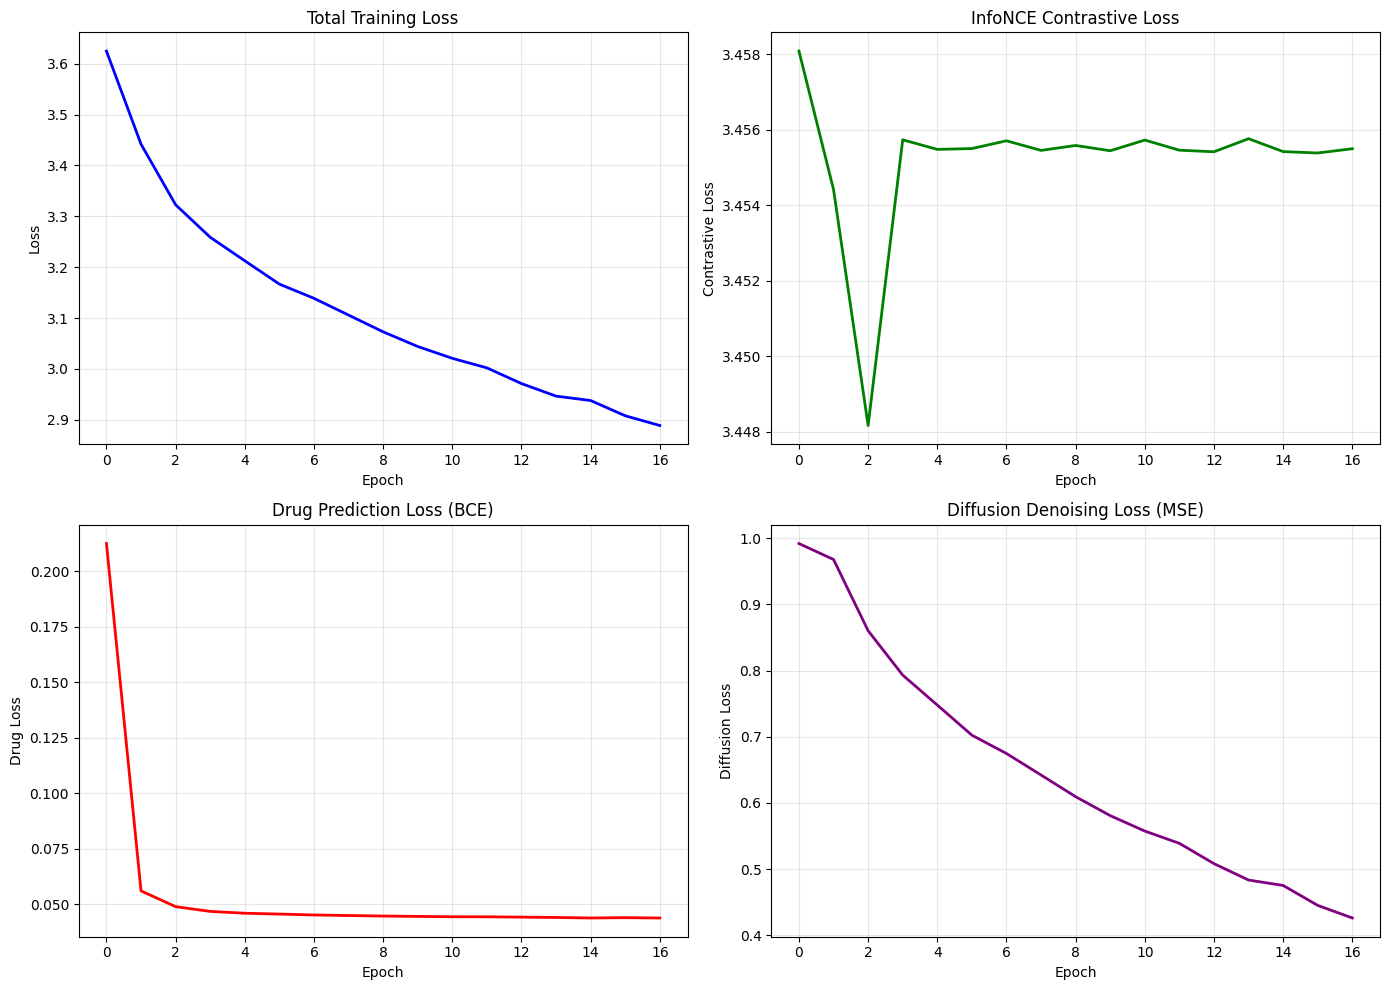


📊 Training Summary:
  Final Total Loss: 2.8886
  Final Contrastive Loss: 3.4555
  Final Drug Loss: 0.0437
  Final Diffusion Loss: 0.4260

----------------------------------------
2. LATENT ALIGNMENT ANALYSIS
----------------------------------------


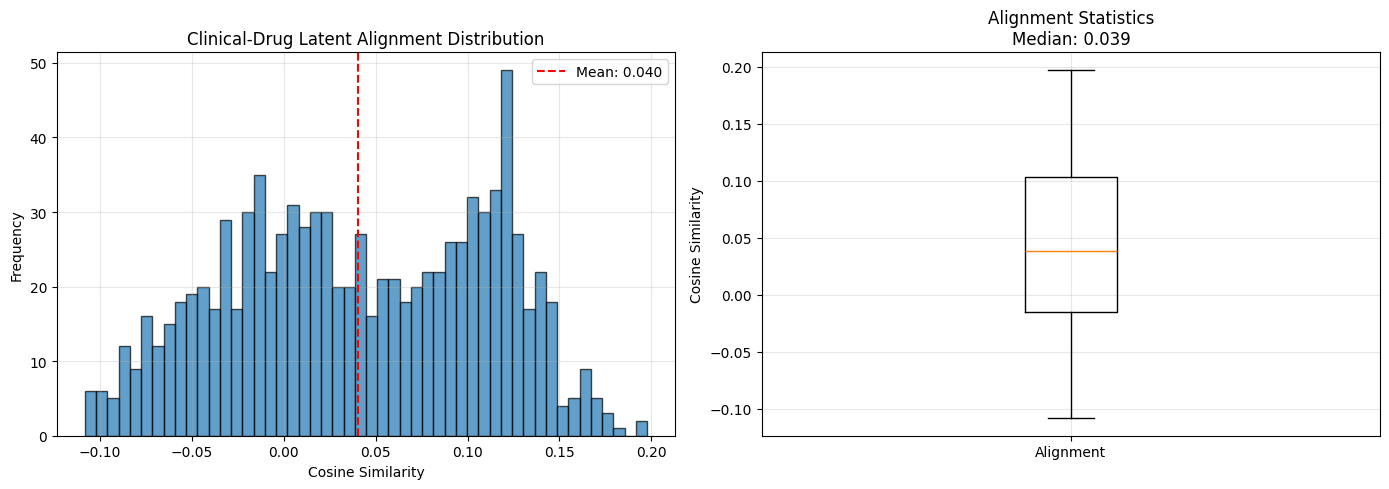


📊 Latent Alignment Statistics:
  Mean similarity: 0.0404
  Std similarity: 0.0698
  Min similarity: -0.1083
  Max similarity: 0.1977
  Median similarity: 0.0388

----------------------------------------
3. DRUG PREDICTION EVALUATION
----------------------------------------

📊 Drug Prediction Evaluation:
  Precision: 0.4203
  Recall:    0.3982
  F1-Score:  0.4089
  Accuracy:  0.9797
  Mean AP:   0.0489

📈 Top 10 Drugs by Average Precision:
  metformin                      AP=0.6446 (prevalence=0.673)
  levothyroxine                  AP=0.3337 (prevalence=0.161)
  losartan                       AP=0.3139 (prevalence=0.236)
  atorvastatin                   AP=0.3139 (prevalence=0.227)
  gliclazide                     AP=0.3038 (prevalence=0.268)
  glibenclamide                  AP=0.2527 (prevalence=0.198)
  aspirin                        AP=0.2507 (prevalence=0.182)
  sitagliptin                    AP=0.0980 (prevalence=0.083)
  amlodipine                     AP=0.0963 (prevalence=0.047

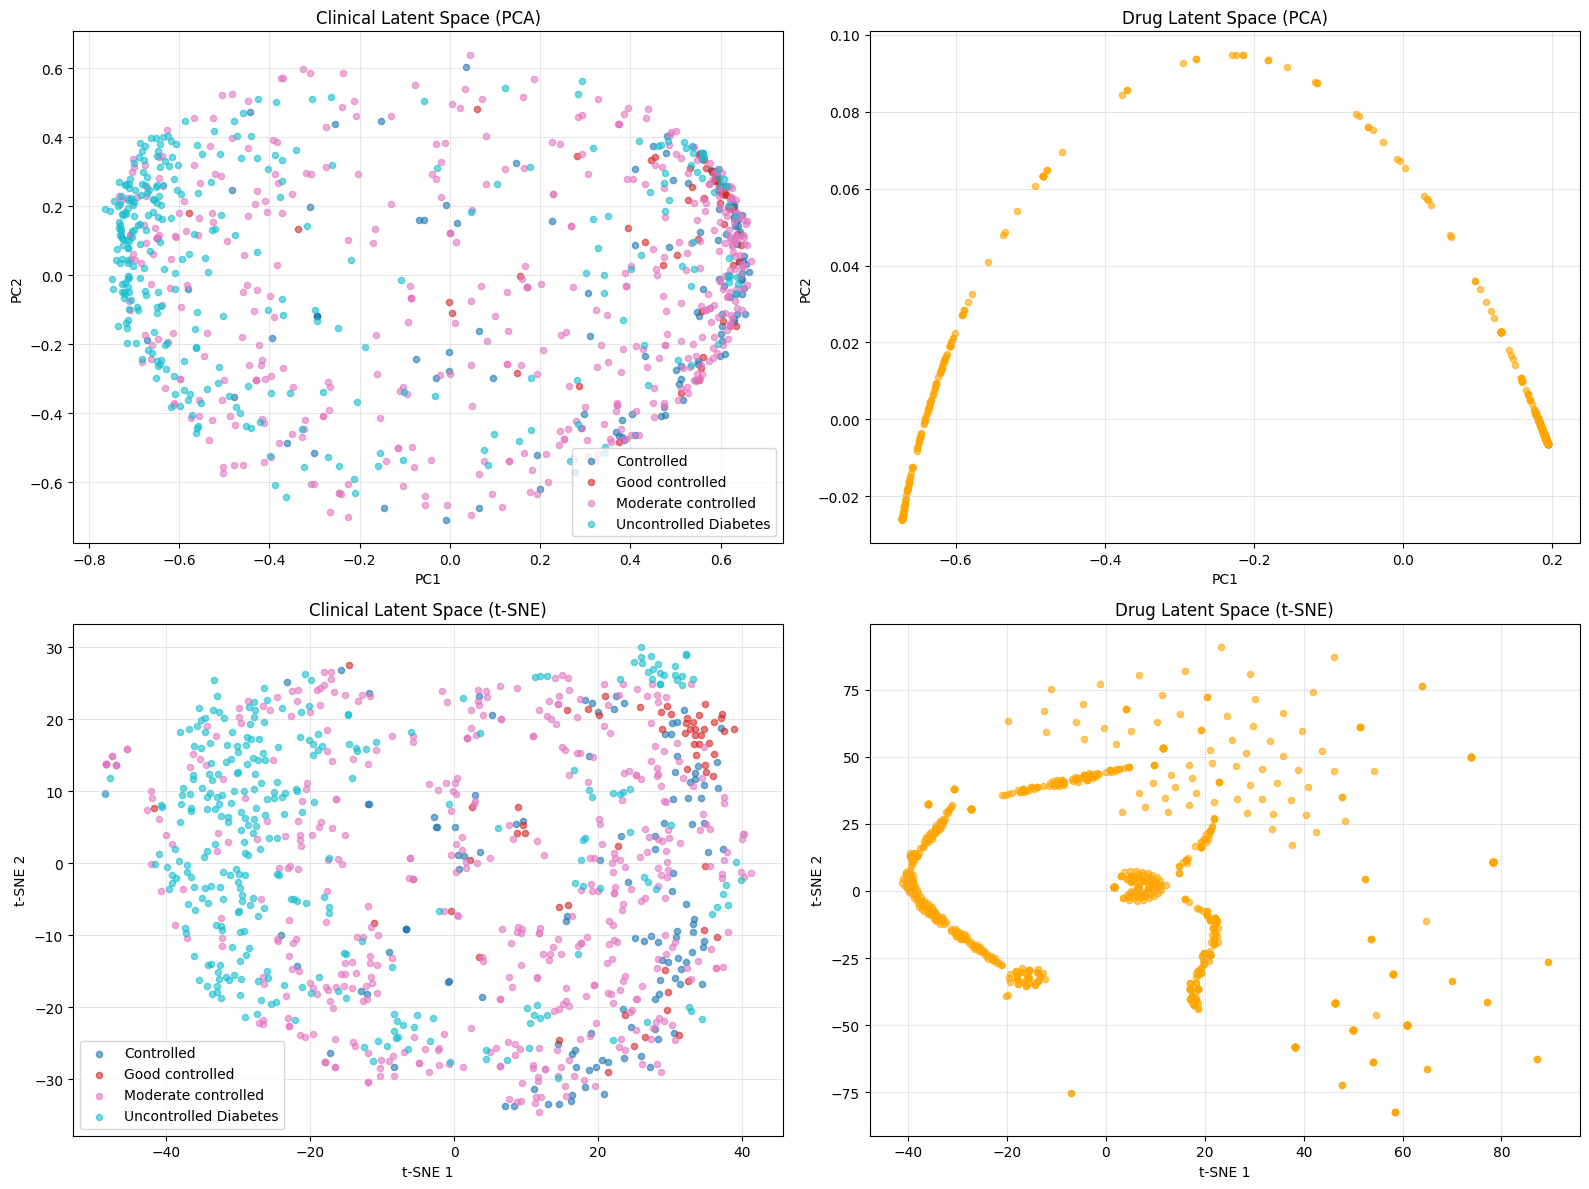


----------------------------------------
5. GENERATION QUALITY
----------------------------------------

🎨 Generation Quality Evaluation:
  Diversity (mean pairwise distance): 0.9530
  Total generated samples: 480
  Average drugs per generated regimen: 1.70

📝 Generation Examples:
  Sample 1: metformin
  Sample 2: atorvastatin, metformin
  Sample 3: atorvastatin, metformin
  Sample 4: atorvastatin, metformin
  Sample 5: atorvastatin, metformin

----------------------------------------
6. DIFFUSION PROCESS VISUALIZATION
----------------------------------------


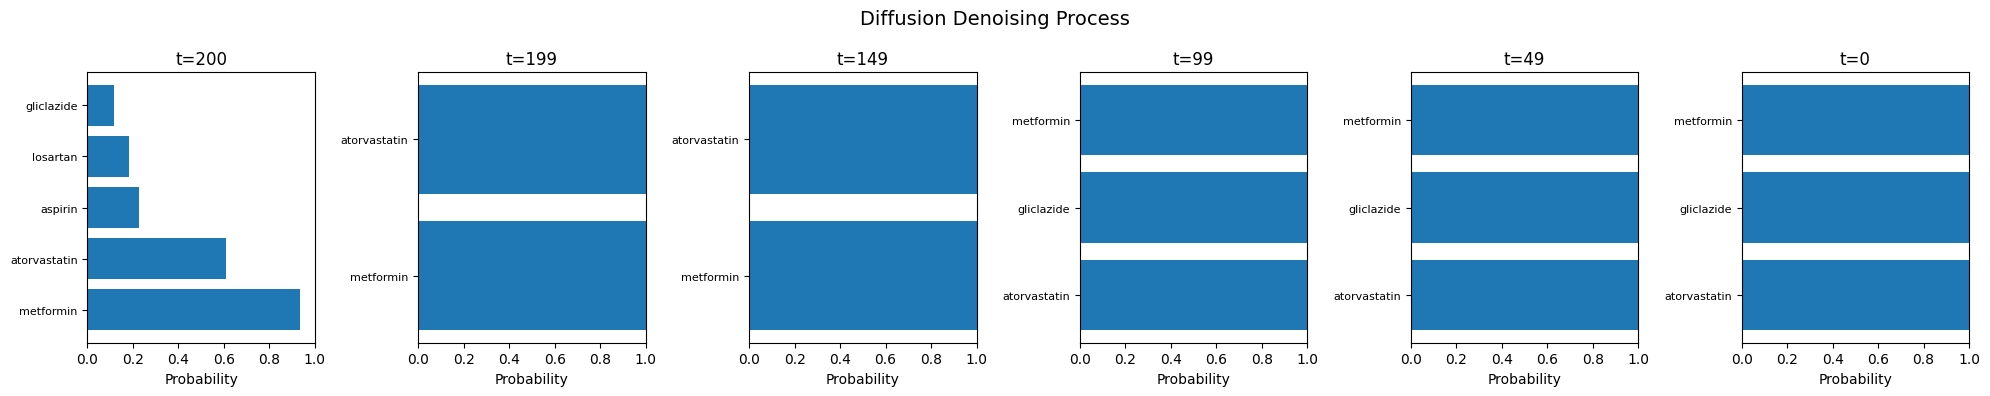


📊 EVALUATION SUMMARY

    Metric                          | Value
    -------------------------------|----------
    Final Training Loss            | 2.8886
    Final Contrastive Loss         | 3.4555
    Final Drug Loss                | 0.0437
    Final Diffusion Loss           | 0.4260
    Clinical-Drug Alignment        | 0.0404
    Drug Prediction F1             | 0.4089
    Drug Prediction Mean AP        | 0.0489
    Generation Diversity           | 0.9530
    

🏦 BUILDING REGIMEN RETRIEVAL BANK

📚 Building regimen latent bank...


Building bank: 100%|██████████| 96/96 [00:02<00:00, 35.72it/s]


✅ Built bank with 3052 regimens

📊 COMPUTING COMPREHENSIVE EVALUATION METRICS


Evaluating metrics: 100%|██████████| 30/30 [00:00<00:00, 35.69it/s]



MAPCT-Diffusion Evaluation Metrics
Drug Prediction (threshold=0.3):
  Accuracy  : 0.9797
  Precision (micro): 0.4203
  Recall    (micro): 0.3982
  F1        (micro): 0.4089
  ROC-AUC (macro)  : 0.5490
  PR-AUC  (macro)  : 0.0489

Alignment:
  Cosine similarity (mean) : 0.0404
  Pearson correlation      : 0.0387
  Spearman correlation     : 0.0522
  Contrastive gap (pos-neg): 0.0022

SELECT MODE:
  1. Concise Interactive Demo
  2. Batch Evaluation
  3. Full Demo (verbose)

🧬 MAPCT-Diffusion COMPLETE MODEL CAPABILITIES DEMO

📋 MODEL CAPABILITIES:
  ✓ Patient Clinical Encoding
  ✓ Drug Prediction (from clinical data)
  ✓ Regimen Generation (Diffusion-based)
  ✓ Regimen Retrieval (from training bank)
  ✓ Clinical-Drug Latent Alignment
  ✓ Drug Mechanism Analysis
  ✓ Drug Similarity Search

PATIENT SELECTION

Select dataset:
  1. Test set (unseen patients - recommended)
  2. Validation set
  3. Training set
  4. Exit

📊 TEST set: 950 patients (0 to 949)

📋 PATIENT 0 - TEST SET

🏥 DEMOGRAPH

In [ ]:
# ============================================================
# ============================================================
# MODEL CREATION & TRAINING (ADD THIS SECTION)
# ============================================================
# ============================================================

print("\n" + "="*80)
print("🚀 STARTING MAPCT-Diffusion TRAINING AND EVALUATION")
print("="*80)

# ============================================================
# Create model instance
# ============================================================
clin_dim = X_clin_train.shape[1]

model = MAPCTDiffusion(
    clin_dim=clin_dim,
    num_drugs=num_drugs,
    latent_dim=128,
    n_timesteps=200,
    beta_start=1e-4,
    beta_end=0.02,
    schedule_type="cosine"
).to(device)

print(f"\n✅ Model initialized:")
print(f"   Clinical input dim: {clin_dim}")
print(f"   Drug vocabulary size: {num_drugs}")
print(f"   Latent dim: 128")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# Create trainer
# ============================================================
trainer = MAPCTDiffusionTrainer(model, device, drug_vocab, drug_to_idx)

# ============================================================
# Train the model
# ============================================================
print("\n" + "="*80)
print("🎯 STARTING TRAINING")
print("="*80)

history = trainer.train(train_loader, val_loader, epochs=50, patience=15)

# ============================================================
# Load best model checkpoint
# ============================================================
if os.path.exists('best_diffusion_model.pt'):
    model.load_state_dict(torch.load('best_diffusion_model.pt', map_location=device))
    print("\n✅ Loaded best model checkpoint")
else:
    print("\n⚠️ No checkpoint found, using current model")

# ============================================================
# Optional: Run comprehensive evaluation
# ============================================================
print("\n" + "="*80)
print("📊 RUNNING COMPREHENSIVE EVALUATION")
print("="*80)

eval_results = comprehensive_evaluation(
    model, trainer, test_loader, clinic_df_test,
    drug_vocab, device
)

# ============================================================
# Build regimen bank for retrieval
# ============================================================
print("\n" + "="*80)
print("🏦 BUILDING REGIMEN RETRIEVAL BANK")
print("="*80)

regimen_bank, regimen_info = build_regimen_bank(model, train_loader, device)


# ========== COMPUTE EVALUATION METRICS ==========
print("\n" + "="*80)
print("📊 COMPUTING COMPREHENSIVE EVALUATION METRICS")
print("="*80)

metrics = compute_evaluation_metrics(model, test_loader, drug_vocab, device, threshold=0.3)
# ============================================================
# ============================================================
# DEMO SELECTION (NOW model AND trainer ARE DEFINED)
# ============================================================
# ============================================================

print("\n" + "="*60)
print("SELECT MODE:")
print("  1. Concise Interactive Demo")
print("  2. Batch Evaluation")
print("  3. Full Demo (verbose)")

mode = input("\nChoice (1-3, default=1): ").strip() or "1"

if mode == "1":
    concise_diffusion_demo(
        model=model,
        clinical_preprocessor=clinical_preprocessor,
        train_df=clinic_df_train,
        val_df=clinic_df_val,
        test_df=clinic_df_test,
        drug_vocab=drug_vocab,
        drug_embeddings=drug_embeddings,
        mech_df=mech_df,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        device=device,
        regimen_bank=regimen_bank,
        regimen_info=regimen_info
    )

elif mode == "2":
    results = batch_evaluation(model, test_loader, clinic_df_test, drug_vocab, device)

else:
    mapct_diffusion_interactive_demo(
        model=model,
        clinical_preprocessor=clinical_preprocessor,
        train_df=clinic_df_train,
        val_df=clinic_df_val,
        test_df=clinic_df_test,
        drug_vocab=drug_vocab,
        drug_embeddings=drug_embeddings,
        mech_df=mech_df,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        device=device,
        regimen_bank=regimen_bank,
        regimen_info=regimen_info
    )

# After training and evaluation, add:
print("\n🎨 Generating joint latent space plots...")
visualize_joint_pca(model, test_loader, device, save_path='joint_pca.png')
visualize_joint_tsne(model, test_loader, device, perplexity=30, save_path='joint_tsne.png')
visualize_joint_umap(model, test_loader, device, n_neighbors=15, save_path='joint_umap.png')

# ========== ADDITIONAL VISUALIZATIONS ==========
print("\n📊 Running additional visualizations...")
plot_training_history(trainer)   # Note: comprehensive_evaluation already does this; you may want to keep it or remove the duplicate
visualize_drug_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50)
find_similar_drugs_by_mechanism(drug_embeddings, "metformin", drug_vocab, top_k=10)
interactive_recommendation_demo(model, clinical_preprocessor, clinic_df_test,
                                 numeric_cols, categorical_cols, device)

print("\n" + "="*80)
print("✅ MAPCT-Diffusion COMPLETE!")
print("="*80)